In [1]:
from sklearn.preprocessing import StandardScaler

# import joblib

# # Load scaler later
# scaler = joblib.load('/work/y_scaler_f_correct.pkl')

In [260]:
import pandas as pd 
from sklearn.model_selection import train_test_split

y = pd.read_csv("AY_DATA.csv", index_col=0, parse_dates=True)
X = pd.read_csv("AX_DATA.csv", index_col=0, parse_dates=True)

X = X[1596:]
y = y[1596:]

In [7]:




# Correcting the syntax error in the provided code

# Install the required libraries
!pip install statsmodels
!pip install xgboost==3.0.2
!pip install POT

# Importing the statsmodels library correctly
import statsmodels.api as sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 42.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 2.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.6/865.6 kB 27.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [117]:

from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import statsmodels.api as sm
import numpy as np
import pandas as pd

from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np

def cluster_coefficients_bayesian_gmm(coefficient_matrix, n_components=5):
    """
    Cluster coefficients using Bayesian GMM and return:
    - hard_labels: Most probable cluster for each coefficient vector
    - soft_probs: Posterior cluster probabilities for each coefficient vector
    - bgmm_model: Fitted BGMM object
    """
    if len(coefficient_matrix) == 0:
        return np.array([]), np.empty((0, n_components)), None

    coeff_clean = np.nan_to_num(coefficient_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(coeff_clean)

    bgmm = BayesianGaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=24,
        max_iter=500
    )
    
    bgmm.fit(coeff_scaled)
    soft_probs = bgmm.predict_proba(coeff_scaled)
    hard_labels = bgmm.predict(coeff_scaled)

    return hard_labels, soft_probs, bgmm


def rolling_coefficient_clustering_pipeline_soft(X, y, features,
                                                 n_clusters=3,
                                                 train_days=441,
                                                 predict_days=5,
                                                 mood_window=20,
                                                 mood_alpha=0.05):
    from scipy.stats import mood

    def mood_segmentation(y, window=mood_window, alpha=mood_alpha):
        change_points = []
        for t in range(window, len(y) - window):
            left = y[t - window:t]
            right = y[t:t + window]
            stat, p = mood(left, right)
            if p < alpha:
                change_points.append(t)
        return sorted(set(change_points))

    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_labels_all = []

    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))

        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        if (X_train_df[features].isnull().any().any() or
            np.isnan(y_train).any() or
            X_test_df[features].isnull().any().any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        change_points = mood_segmentation(y_train)
        if not change_points:
            change_points = [len(y_train) // 2]

        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))

        segment_coefficients = []
        segment_info = []

        for i in range(len(change_points) - 1):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            if end_idx - start_idx < len(features) + 2:
                continue
            X_segment = X_train_df.iloc[start_idx:end_idx]
            y_segment = y_train[start_idx:end_idx]
            try:
                model = sm.OLS(y_segment, sm.add_constant(X_segment[features])).fit()
                coeffs = model.params.values
                is_ols = True
            except:
                model = Ridge(alpha=1e-3)
                model.fit(X_segment[features], y_segment)
                coeffs = np.concatenate([[model.intercept_], model.coef_])
                is_ols = False
            segment_coefficients.append(coeffs)
            segment_info.append({
                'start': start_idx,
                'end': end_idx,
                'model': model,
                'type': 'ols' if is_ols else 'ridge'
            })

        if len(segment_coefficients) == 0:
            model = Ridge(alpha=1e-3)
            model.fit(X_train_df[features], y_train)
            coeffs = np.concatenate([[model.intercept_], model.coef_])
            segment_coefficients = [coeffs]
            segment_info = [{
                'start': 0,
                'end': len(y_train),
                'model': model,
                'type': 'ridge'
            }]

        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, segment_probs, bgmm_model = cluster_coefficients_bayesian_gmm(
            coefficient_matrix, n_components=n_clusters
        )

        point_labels_train = np.zeros(len(y_train), dtype=int)
        point_probs_train = np.zeros((len(y_train), n_clusters))

        for i, seg in enumerate(segment_info):
            if i < len(segment_labels):
                point_labels_train[seg['start']:seg['end']] = segment_labels[i]
                point_probs_train[seg['start']:seg['end']] = segment_probs[i]

        cluster_models = {}
        for k in range(n_clusters):
            mask = point_labels_train == k
            if np.sum(mask) < len(features) + 1:
                continue
            try:
                model = sm.OLS(y_train[mask], sm.add_constant(X_train_df.loc[mask, features])).fit()
                cluster_models[k] = {'model': model, 'type': 'ols'}
            except:
                ridge = Ridge(alpha=1e-3)
                ridge.fit(X_train_df.loc[mask, features], y_train[mask])
                cluster_models[k] = {'model': ridge, 'type': 'ridge'}

        # Step 6: Soft prediction
        preds = np.zeros(current_predict_days)
        for k in range(n_clusters):
            if k not in cluster_models:
                continue
            try:
                if cluster_models[k]['type'] == 'ols':
                    X_test_const = sm.add_constant(X_test_df[features], has_constant='add')
                    expected_cols = cluster_models[k]['model'].model.exog_names
                    X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
                    cluster_preds = cluster_models[k]['model'].predict(X_test_const)
                else:
                    cluster_preds = cluster_models[k]['model'].predict(X_test_df[features])
                last_probs = segment_probs[-1][k] if len(segment_probs) > 0 else 1 / n_clusters
                preds += cluster_preds * last_probs
            except Exception as e:
                print(f"Prediction failed for cluster {k} in window {window_count}: {e}")

        predictions.extend(preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))
        test_cluster_labels_all.extend([segment_labels[-1]] * current_predict_days)

        start += predict_days

    return (np.array(predictions),
            np.array(prediction_indices),
            np.array(test_cluster_labels_all))


In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from xgboost import XGBClassifier
from scipy.stats import mood
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

def mood_segmentation(y, window=20, alpha=0.05):
    """
    Perform mood test segmentation with specified window size.
    """
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

# import ruptures as rpt

# def ruptures_segmentation(y, model="rbf", pen=10, min_size=5):
#     """
#     Segment time series using ruptures (e.g., for volatility regime changes),
#     ensuring each segment has at least `min_size` data points.

#     Parameters:
#     - y: array-like, 1D time series (e.g., log(RV))
#     - model: str, e.g., 'rbf', 'l2'
#     - pen: float, segmentation penalty (higher = fewer segments)
#     - min_size: int, minimum number of points per segment

#     Returns:
#     - List of valid change point indices (excluding 0 and len(y))
#     """
#     y_array = np.asarray(y).reshape(-1, 1)
#     algo = rpt.Pelt(model=model, min_size=min_size).fit(y_array)
#     raw_cps = algo.predict(pen=pen)

#     # Drop the final index (len(y)) — you handle it later
#     raw_cps = [cp for cp in raw_cps if cp < len(y)]

#     # Remove change points that would create a segment < min_size
#     change_points = []
#     prev_cp = 0
#     for cp in raw_cps:
#         if cp - prev_cp >= min_size:
#             change_points.append(cp)
#             prev_cp = cp

#     # Also enforce that the final segment is at least min_size
#     if len(y) - (change_points[-1] if change_points else 0) < min_size:
#         change_points = change_points[:-1]  # drop last one if it's too close to end

#     return change_points


def calculate_linear_regression_coefficients(X, y, features):
    """
    Calculate linear regression coefficients for all features in X on y.
    Returns coefficient vector including intercept.
    """
    try:
        X_features = X[features].copy()
        X_const = sm.add_constant(X_features, has_constant='add')
        model = sm.OLS(y, X_const).fit()
        coefficients = model.params.values
        return coefficients, model, True
    except Exception as e:
        # Fallback with Ridge regression if OLS fails
        try:
            from sklearn.linear_model import Ridge
            X_features = X[features].copy()
            ridge = Ridge(alpha=1e-3, fit_intercept=True)
            ridge.fit(X_features, y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            # Ultimate fallback - return zeros
            coefficients = np.zeros(len(features) + 1)  # +1 for intercept
            return coefficients, None, False

def cluster_coefficients_knn_euclidean(coefficient_matrix, n_clusters=3):
    """
    Cluster coefficient vectors using KMeans with euclidean distance.
    Note: Despite the name suggesting KNN, we use KMeans for clustering as KNN is for classification/regression.
    The euclidean distance is inherent in KMeans.
    """
    if len(coefficient_matrix) == 0:
        return np.array([]), None, None
    
    if len(coefficient_matrix) < n_clusters:
        # If fewer segments than clusters, assign sequential labels
        labels = np.arange(len(coefficient_matrix)) % n_clusters
        return labels, None, None
    
    # Remove any rows with all NaN or inf values
    valid_rows = ~(np.isnan(coefficient_matrix).all(axis=1) | np.isinf(coefficient_matrix).all(axis=1))
    if not np.any(valid_rows):
        labels = np.zeros(len(coefficient_matrix), dtype=int)
        return labels, None, None
    
    # Handle NaN/inf values by replacing with 0
    coeff_clean = np.nan_to_num(coefficient_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Standardize coefficients for clustering
    scaler = StandardScaler()
    try:
        coefficients_scaled = scaler.fit_transform(coeff_clean)
    except:
        # If scaling fails, use original
        # coefficients_scaled = coeff_clean
        # scaler = None
    
    # Use KMeans for clustering with euclidean distance (default metric)
    kmeans = KMeans(n_clusters=n_clusters, random_state=24, n_init=10, algorithm='lloyd')
    cluster_labels = kmeans.fit_predict(coefficients_scaled)
    
    return cluster_labels, kmeans, scaler

def rolling_coefficient_clustering_pipeline(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=30,
                                          mood_alpha=0.05,
                                          xgb_param_dist=None,
                                          xgb_tuning_iter=25):
    """
    Rolling window pipeline with coefficient clustering approach.
    
    Pipeline:
    1. Mood test segmentation (window=30)
    2. Calculate linear regression coefficients for each segment
    3. Cluster coefficients using KMeans with euclidean distance
    4. Train XGBoost on original features to predict cluster membership
    5. Build cluster-specific models and make predictions
    """
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y
        
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_labels_all = []

    if xgb_param_dist is None:
        xgb_param_dist = {
            "n_estimators": [50, 100, 150],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }

    start = 0
    window_count = 0
    
    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))

        # Extract training and test data
        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        # Check for missing data
        if (X_train_df[features].isnull().any().any() or 
            np.isnan(y_train).any() or 
            X_test_df[features].isnull().any().any()):
            print(f"Warning: Skipping window {window_count} at index {start} due to NaNs.")
            start += predict_days
            continue

        # Step 1: Mood test segmentation with window=5
        change_points = mood_segmentation(y_train)
        
        # Ensure we have valid segments
        if not change_points:
            change_points = [len(y_train) // 2]  # Single split if no change points
        
        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))  # Remove duplicates and sort

        # Step 2: Calculate linear regression coefficients for each segment
        segment_coefficients = []
        segment_info = []
        
        for i in range(len(change_points) - 1):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            
            if end_idx - start_idx < len(features) + 2:  # Need minimum observations
                continue
                
            X_segment = X_train_df.iloc[start_idx:end_idx]
            y_segment = y_train[start_idx:end_idx]
            
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_segment, y_segment, features)
            
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({
                    'start': start_idx,
                    'end': end_idx,
                    'model': model,
                    'is_ols': is_ols
                })

        # Handle case where no valid segments
        if len(segment_coefficients) == 0:
            print(f"Warning: No valid segments in window {window_count}. Using single segment.")
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{
                'start': 0,
                'end': len(y_train),
                'model': model,
                'is_ols': is_ols
            }]

        # Step 3: Cluster coefficients using KMeans with euclidean distance
        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, kmeans_model, coeff_scaler = cluster_coefficients_knn_euclidean(
            coefficient_matrix, n_clusters=n_clusters
        )

        # Step 4: Assign point-wise cluster labels based on segment clustering
        point_labels_train = np.zeros(len(y_train), dtype=int)
        
        for i, segment_info_item in enumerate(segment_info):
            if i < len(segment_labels):
                start_idx = segment_info_item['start']
                end_idx = segment_info_item['end']
                point_labels_train[start_idx:end_idx] = segment_labels[i]

        # Step 5: Train XGBoost classifier on original features (no modification)
        try:
            xgb_clf = XGBClassifier(
                use_label_encoder=False, 
                eval_metric='mlogloss', 
                random_state=24,
                verbosity=0
            )
            
            # random_search = RandomizedSearchCV(
            #     xgb_clf,
            #     xgb_param_dist,
            #     n_iter=xgb_tuning_iter,
            #     cv=min(3, len(np.unique(point_labels_train))),
            #     verbose=0,
            #     n_jobs=1,  # Reduced from -1 to avoid potential issues
            #     random_state=24,
            #     scoring='neg_log_loss'
            # )
            
            # # Fit XGBoost on original features X (no modification)
            # random_search.fit(X_train_df[features], point_labels_train)
            # best_xgb = random_search.best_estimator_
            best_xgb = xgb_clf

            best_xgb.fit(X_train_df[features], point_labels_train)
            
        except Exception as e:
            print(f"Warning: XGBoost training failed in window {window_count}: {e}")
            # Fallback: use simple majority class predictor
            from sklearn.dummy import DummyClassifier
            best_xgb = DummyClassifier(strategy='most_frequent')
            best_xgb.fit(X_train_df[features], point_labels_train)

        # Step 6: Predict cluster labels for test set
        try:
            point_labels_test = best_xgb.predict(X_test_df[features])
        except Exception as e:
            print(f"Warning: XGBoost prediction failed in window {window_count}: {e}")
            # Fallback: assign most common cluster
            point_labels_test = np.full(current_predict_days, 
                                      np.bincount(point_labels_train).argmax())
        
        test_cluster_labels_all.extend(point_labels_test)

        # Step 7: Build cluster-specific HAR models using original features
        cluster_har_models = {}
        
        for cluster in range(n_clusters):
            cluster_mask = (point_labels_train == cluster)
            if not np.any(cluster_mask):
                continue
            
            X_cluster = X_train_df.loc[cluster_mask, features]
            y_cluster = y_train[cluster_mask]
            
            if len(X_cluster) > len(features) + 1:  # Ensure sufficient data
                try:
                    X_cluster_const = sm.add_constant(X_cluster, has_constant='add')
                    model = sm.OLS(y_cluster, X_cluster_const).fit()
                    cluster_har_models[cluster] = {'model': model, 'type': 'ols'}
                except:
                    # Fallback to Ridge regression
                    from sklearn.linear_model import Ridge
                    ridge = Ridge(alpha=1e-3, fit_intercept=True)
                    ridge.fit(X_cluster, y_cluster)
                    cluster_har_models[cluster] = {'model': ridge, 'type': 'ridge'}

        # Step 8: Make predictions using cluster-specific models
        preds = np.full(current_predict_days, np.mean(y_train))  # Default fallback
        
        for cluster in range(n_clusters):
            cluster_mask = (point_labels_test == cluster)
            if not np.any(cluster_mask) or cluster not in cluster_har_models:
                continue
            
            X_test_cluster = X_test_df.loc[cluster_mask, features]
            
            try:
                if cluster_har_models[cluster]['type'] == 'ols':
                    # For statsmodels OLS
                    X_test_const = sm.add_constant(X_test_cluster, has_constant='add')
                    expected_cols = cluster_har_models[cluster]['model'].model.exog_names
                    X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
                    cluster_preds = cluster_har_models[cluster]['model'].predict(X_test_const)
                else:
                    # For sklearn Ridge
                    cluster_preds = cluster_har_models[cluster]['model'].predict(X_test_cluster)
                
                preds[cluster_mask] = cluster_preds
                
            except Exception as e:
                print(f"Warning: Prediction failed for cluster {cluster} in window {window_count}: {e}")
                # Keep default prediction

        predictions.extend(preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))

        start += predict_days

    return (np.array(predictions),
            np.array(prediction_indices),
            np.array(test_cluster_labels_all))

# # Visualization function
# def plot_results(X, y_true, predictions, prediction_indices, test_cluster_labels_all, scaler=None):
#     """
#     Plot the results with cluster-colored predictions.
#     """
#     # Handle inverse transform if scaler provided
#     if scaler is not None:
#         y_true_is = y_true if isinstance(y_true, np.ndarray) else y_true.values
#         y_hat_is = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
#     else:
#         y_true_is = y_true.flatten() if hasattr(y_true, 'flatten') else np.array(y_true)
#         y_hat_is = np.array(predictions).flatten()

#     # Get datetime index for predictions  
#     try:
#         prediction_dates = X.iloc[prediction_indices].index
#     except IndexError:
#         # Handle case where indices might be out of bounds
#         valid_indices = [i for i in prediction_indices if i < len(X)]
#         prediction_dates = X.iloc[valid_indices].index
#         y_hat_is = y_hat_is[:len(valid_indices)]
#         test_cluster_labels_all = test_cluster_labels_all[:len(valid_indices)]

#     # Define color map
#     cluster_colors = {0: 'xkcd:pinkish', 1: 'pink', 2: 'purple', 3: 'cyan', 4: 'orange'}

#     # Create the plot
#     fig, ax = plt.subplots(figsize=(14, 6))
    
#     # Plot true values
#     try:
#         true_dates = X.iloc[prediction_indices].index
#         ax.plot(true_dates, y_true_is[:len(true_dates)], 
#                 label='Realized Volatility (SPX)', 
#                 linewidth=2, linestyle='dashed', color='olive')
#     except:
#         ax.plot(prediction_dates, y_true_is[:len(prediction_dates)], 
#                 label='Realized Volatility (SPX)', 
#                 linewidth=2, linestyle='dashed', color='olive')

#     # Plot predicted volatility with color by cluster
#     if len(y_hat_is) > 0 and len(test_cluster_labels_all) > 0:
#         test_cluster_labels_array = np.array(test_cluster_labels_all)
        
#         start_idx = 0
#         for i in range(1, len(y_hat_is)):
#             if (i >= len(test_cluster_labels_array) or 
#                 test_cluster_labels_array[i] != test_cluster_labels_array[start_idx] or 
#                 i == len(y_hat_is) - 1):
                
#                 end_idx = min(i + 1, len(prediction_dates), len(y_hat_is))
#                 segment_x = prediction_dates[start_idx:end_idx]
#                 segment_y = y_hat_is[start_idx:end_idx]
                
#                 if start_idx < len(test_cluster_labels_array):
#                     cluster_id = test_cluster_labels_array[start_idx]
#                     color = cluster_colors.get(cluster_id, 'gray')
                    
#                     ax.plot(segment_x, segment_y, color=color, linewidth=2,
#                             label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
                
#                 start_idx = i

#     # Set title and labels
#     ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
#     ax.set_xlabel('Date')
#     ax.set_ylabel('Volatility')
#     ax.grid(True)

#     # Format x-axis
#     ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
#     plt.xticks(rotation=45)

#     ax.legend()
#     plt.tight_layout()
#     plt.show()

# Example usage:
# predictions, prediction_indices, test_cluster_labels_all = rolling_coefficient_clustering_pipeline(
#     X, y, features, n_clusters=3, train_days=441, predict_days=5, mood_window=30
# )
# plot_results(X, y_true, predictions, prediction_indices, test_cluster_labels_all, scaler)

IndentationError: expected an indented block after 'except' statement on line 119 (2662230060.py, line 125)

In [24]:
def rolling_coefficient_clustering_pipeline_soft(X, y, features,
                                                n_clusters=3,
                                                train_days=441,
                                                predict_days=5,
                                                mood_window=30,
                                                mood_alpha=0.05,
                                                xgb_param_dist=None,
                                                xgb_tuning_iter=25):
    """
    Rolling window pipeline with coefficient clustering and soft cluster assignment via XGBoost probabilities.
    
    Returns predictions (weighted by soft cluster membership),
    prediction indices, and test cluster probabilities.
    """
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_probabilities_all = []

    if xgb_param_dist is None:
        xgb_param_dist = {
            "n_estimators": [50, 100, 150],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }

    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))

        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        if (X_train_df[features].isnull().any().any() or 
            np.isnan(y_train).any() or 
            X_test_df[features].isnull().any().any()):
            print(f"Warning: Skipping window {window_count} at index {start} due to NaNs.")
            start += predict_days
            continue

        # Mood segmentation & coefficient extraction (same as before)
        change_points = mood_segmentation(y_train)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))

        segment_coefficients = []
        segment_info = []

        for i in range(len(change_points) - 1):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            if end_idx - start_idx < len(features) + 2:
                continue
            X_segment = X_train_df.iloc[start_idx:end_idx]
            y_segment = y_train[start_idx:end_idx]
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_segment, y_segment, features)
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({'start': start_idx, 'end': end_idx, 'model': model, 'is_ols': is_ols})

        if len(segment_coefficients) == 0:
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model, 'is_ols': is_ols}]

        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, kmeans_model, coeff_scaler = cluster_coefficients_knn_euclidean(coefficient_matrix, n_clusters=n_clusters)

        # Assign hard segment cluster labels to training points (needed for supervised XGB training)
        point_labels_train = np.zeros(len(y_train), dtype=int)
        for i, seg in enumerate(segment_info):
            if i < len(segment_labels):
                point_labels_train[seg['start']:seg['end']] = segment_labels[i]

        # Train XGB classifier (same as before)
        try:
            xgb_clf = XGBClassifier(
                use_label_encoder=False, 
                eval_metric='mlogloss', 
                random_state=24,
                verbosity=0
            )
            best_xgb = xgb_clf
            best_xgb.fit(X_train_df[features], point_labels_train)
        except Exception as e:
            print(f"Warning: XGBoost training failed in window {window_count}: {e}")
            from sklearn.dummy import DummyClassifier
            best_xgb = DummyClassifier(strategy='most_frequent')
            best_xgb.fit(X_train_df[features], point_labels_train)

        # --- SOFT CLUSTER PROBABILITIES ---
        try:
            point_labels_test_prob = best_xgb.predict_proba(X_test_df[features])  # shape (test_samples, n_clusters)
        except Exception as e:
            print(f"Warning: XGBoost prediction probs failed in window {window_count}: {e}")
            # fallback: uniform probabilities
            point_labels_test_prob = np.full((current_predict_days, n_clusters), 1.0 / n_clusters)

        test_cluster_probabilities_all.append(point_labels_test_prob)

        # Cluster-specific models
        cluster_har_models = {}
        for cluster in range(n_clusters):
            cluster_mask = (point_labels_train == cluster)
            if not np.any(cluster_mask):
                continue
            X_cluster = X_train_df.loc[cluster_mask, features]
            y_cluster = y_train[cluster_mask]
            if len(X_cluster) > len(features) + 1:
                try:
                    X_cluster_const = sm.add_constant(X_cluster, has_constant='add')
                    model = sm.OLS(y_cluster, X_cluster_const).fit()
                    cluster_har_models[cluster] = {'model': model, 'type': 'ols'}
                except:
                    from sklearn.linear_model import Ridge
                    ridge = Ridge(alpha=1e-3, fit_intercept=True)
                    ridge.fit(X_cluster, y_cluster)
                    cluster_har_models[cluster] = {'model': ridge, 'type': 'ridge'}

        # --- SOFT PREDICTIONS: weighted average across clusters ---
        preds = np.full(current_predict_days, np.mean(y_train))  # fallback

        for cluster in range(n_clusters):
            if cluster not in cluster_har_models:
                continue
            # Predict for all test points with cluster-specific model
            try:
                if cluster_har_models[cluster]['type'] == 'ols':
                    X_test_const = sm.add_constant(X_test_df[features], has_constant='add')
                    expected_cols = cluster_har_models[cluster]['model'].model.exog_names
                    X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
                    cluster_preds = cluster_har_models[cluster]['model'].predict(X_test_const)
                else:
                    cluster_preds = cluster_har_models[cluster]['model'].predict(X_test_df[features])
            except Exception as e:
                print(f"Warning: Prediction failed for cluster {cluster} in window {window_count}: {e}")
                cluster_preds = np.full(current_predict_days, np.mean(y_train))

            # Weight predictions by soft cluster probability
            preds += cluster_preds * point_labels_test_prob[:, cluster]

        # Because we initialized preds with mean(y_train), we added it once. To fix, subtract the mean once.
        preds -= np.mean(y_train)

        predictions.extend(preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))

        start += predict_days

    return (np.array(predictions),
            np.array(prediction_indices),
            np.vstack(test_cluster_probabilities_all))


In [27]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from xgboost import XGBClassifier
from scipy.stats import mood
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

def mood_segmentation(y, window=30, alpha=0.05):
    """
    Perform mood test segmentation with specified window size.
    """
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

import ruptures as rpt

# def ruptures_segmentation(y, model="rbf", pen=10, min_size=30):
#     """
#     Segment time series using ruptures (e.g., for volatility regime changes),
#     ensuring each segment has at least `min_size` data points.

#     Parameters:
#     - y: array-like, 1D time series (e.g., log(RV))
#     - model: str, e.g., 'rbf', 'l2'
#     - pen: float, segmentation penalty (higher = fewer segments)
#     - min_size: int, minimum number of points per segment

#     Returns:
#     - List of valid change point indices (excluding 0 and len(y))
#     """
#     y_array = np.asarray(y).reshape(-1, 1)
#     algo = rpt.Pelt(model=model, min_size=min_size).fit(y_array)
#     raw_cps = algo.predict(pen=pen)

#     # Drop the final index (len(y)) — you handle it later
#     raw_cps = [cp for cp in raw_cps if cp < len(y)]

#     # Remove change points that would create a segment < min_size
#     change_points = []
#     prev_cp = 0
#     for cp in raw_cps:
#         if cp - prev_cp >= min_size:
#             change_points.append(cp)
#             prev_cp = cp

#     # Also enforce that the final segment is at least min_size
#     if len(y) - (change_points[-1] if change_points else 0) < min_size:
#         change_points = change_points[:-1]  # drop last one if it's too close to end

#     return change_points


def calculate_linear_regression_coefficients(X, y, features):
    """
    Calculate linear regression coefficients for all features in X on y.
    Returns coefficient vector including intercept.
    """
    try:
        X_features = X[features].copy()
        X_const = sm.add_constant(X_features, has_constant='add')
        model = sm.OLS(y, X_const).fit()
        coefficients = model.params.values
        return coefficients, model, True
    except Exception as e:
        # Fallback with Ridge regression if OLS fails
        try:
            from sklearn.linear_model import Ridge
            X_features = X[features].copy()
            ridge = Ridge(alpha=1e-3, fit_intercept=True)
            ridge.fit(X_features, y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            # Ultimate fallback - return zeros
            coefficients = np.zeros(len(features) + 1)  # +1 for intercept
            return coefficients, None, False

def cluster_coefficients_knn_euclidean(coefficient_matrix, n_clusters=3):
    """
    Cluster coefficient vectors using KMeans with euclidean distance.
    Note: Despite the name suggesting KNN, we use KMeans for clustering as KNN is for classification/regression.
    The euclidean distance is inherent in KMeans.
    """
    if len(coefficient_matrix) == 0:
        return np.array([]), None, None
    
    if len(coefficient_matrix) < n_clusters:
        # If fewer segments than clusters, assign sequential labels
        labels = np.arange(len(coefficient_matrix)) % n_clusters
        return labels, None, None
    
    # Remove any rows with all NaN or inf values
    valid_rows = ~(np.isnan(coefficient_matrix).all(axis=1) | np.isinf(coefficient_matrix).all(axis=1))
    if not np.any(valid_rows):
        labels = np.zeros(len(coefficient_matrix), dtype=int)
        return labels, None, None
    
    # Handle NaN/inf values by replacing with 0
    coeff_clean = np.nan_to_num(coefficient_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Standardize coefficients for clustering
    scaler = StandardScaler()
    try:
        coefficients_scaled = scaler.fit_transform(coeff_clean)
    except:
        # If scaling fails, use original
        coefficients_scaled = coeff_clean
        scaler = None
    
    # Use KMeans for clustering with euclidean distance (default metric)
    kmeans = KMeans(n_clusters=n_clusters, random_state=24, n_init=10, algorithm='lloyd')
    cluster_labels = kmeans.fit_predict(coefficients_scaled)
    
    return cluster_labels, kmeans, scaler

def rolling_coefficient_clustering_pipeline_soft(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=30,
                                          mood_alpha=0.05,
                                          xgb_param_dist=None,
                                          xgb_tuning_iter=25):
    """
    Rolling window pipeline with coefficient clustering approach.
    
    Pipeline:
    1. Mood test segmentation (window=30)
    2. Calculate linear regression coefficients for each segment
    3. Cluster coefficients using KMeans with euclidean distance
    4. Train XGBoost on original features to predict cluster membership
    5. Build cluster-specific models and make predictions
    """
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y
        
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_labels_all = []

    if xgb_param_dist is None:
        xgb_param_dist = {
            "n_estimators": [50, 100, 150],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }

    start = 0
    window_count = 0
    
    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))

        # Extract training and test data
        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        # Check for missing data
        if (X_train_df[features].isnull().any().any() or 
            np.isnan(y_train).any() or 
            X_test_df[features].isnull().any().any()):
            print(f"Warning: Skipping window {window_count} at index {start} due to NaNs.")
            start += predict_days
            continue

        # Step 1: Mood test segmentation with window=30
        change_points = mood_segmentation(y_train)
        
        # Ensure we have valid segments
        if not change_points:
            change_points = [len(y_train) // 2]  # Single split if no change points
        
        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))  # Remove duplicates and sort

        # Step 2: Calculate linear regression coefficients for each segment
        segment_coefficients = []
        segment_info = []
        
        for i in range(len(change_points) - 1):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            
            if end_idx - start_idx < len(features) + 2:  # Need minimum observations
                continue
                
            X_segment = X_train_df.iloc[start_idx:end_idx]
            y_segment = y_train[start_idx:end_idx]
            
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_segment, y_segment, features)
            
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({
                    'start': start_idx,
                    'end': end_idx,
                    'model': model,
                    'is_ols': is_ols
                })

        # Handle case where no valid segments
        if len(segment_coefficients) == 0:
            print(f"Warning: No valid segments in window {window_count}. Using single segment.")
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{
                'start': 0,
                'end': len(y_train),
                'model': model,
                'is_ols': is_ols
            }]

        # Step 3: Cluster coefficients using KMeans with euclidean distance
        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, kmeans_model, coeff_scaler = cluster_coefficients_knn_euclidean(
            coefficient_matrix, n_clusters=n_clusters
        )

        # Step 4: Assign point-wise cluster labels based on segment clustering
        point_labels_train = np.zeros(len(y_train), dtype=int)
        
        for i, segment_info_item in enumerate(segment_info):
            if i < len(segment_labels):
                start_idx = segment_info_item['start']
                end_idx = segment_info_item['end']
                point_labels_train[start_idx:end_idx] = segment_labels[i]

        # Step 5: Train XGBoost classifier on original features (no modification)
        try:
            xgb_clf = XGBClassifier(
                use_label_encoder=False, 
                eval_metric='mlogloss', 
                random_state=24,
                verbosity=0
            )
            
            # random_search = RandomizedSearchCV(
            #     xgb_clf,
            #     xgb_param_dist,
            #     n_iter=xgb_tuning_iter,
            #     cv=min(3, len(np.unique(point_labels_train))),
            #     verbose=0,
            #     n_jobs=1,  # Reduced from -1 to avoid potential issues
            #     random_state=24,
            #     scoring='neg_log_loss'
            # )
            
            # # Fit XGBoost on original features X (no modification)
            # random_search.fit(X_train_df[features], point_labels_train)
            # best_xgb = random_search.best_estimator_
            best_xgb = xgb_clf

            best_xgb.fit(X_train_df[features], point_labels_train)
            
        except Exception as e:
            print(f"Warning: XGBoost training failed in window {window_count}: {e}")
            # Fallback: use simple majority class predictor
            from sklearn.dummy import DummyClassifier
            best_xgb = DummyClassifier(strategy='most_frequent')
            best_xgb.fit(X_train_df[features], point_labels_train)

        # Step 6: Predict cluster labels for test set
        try:
            point_labels_test = best_xgb.predict(X_test_df[features])
        except Exception as e:
            print(f"Warning: XGBoost prediction failed in window {window_count}: {e}")
            # Fallback: assign most common cluster
            point_labels_test = np.full(current_predict_days, 
                                      np.bincount(point_labels_train).argmax())
        
        test_cluster_labels_all.extend(point_labels_test)

        # Step 7: Build cluster-specific HAR models using original features
        cluster_har_models = {}
        
        for cluster in range(n_clusters):
            cluster_mask = (point_labels_train == cluster)
            if not np.any(cluster_mask):
                continue
            
            X_cluster = X_train_df.loc[cluster_mask, features]
            y_cluster = y_train[cluster_mask]
            
            if len(X_cluster) > len(features) + 1:  # Ensure sufficient data
                try:
                    X_cluster_const = sm.add_constant(X_cluster, has_constant='add')
                    model = sm.OLS(y_cluster, X_cluster_const).fit()
                    cluster_har_models[cluster] = {'model': model, 'type': 'ols'}
                except:
                    # Fallback to Ridge regression
                    from sklearn.linear_model import Ridge
                    ridge = Ridge(alpha=1e-3, fit_intercept=True)
                    ridge.fit(X_cluster, y_cluster)
                    cluster_har_models[cluster] = {'model': ridge, 'type': 'ridge'}

        # Step 8: Make predictions using cluster-specific models
        preds = np.full(current_predict_days, np.mean(y_train))  # Default fallback
        
        for cluster in range(n_clusters):
            cluster_mask = (point_labels_test == cluster)
            if not np.any(cluster_mask) or cluster not in cluster_har_models:
                continue
            
            X_test_cluster = X_test_df.loc[cluster_mask, features]
            
            try:
                if cluster_har_models[cluster]['type'] == 'ols':
                    # For statsmodels OLS
                    X_test_const = sm.add_constant(X_test_cluster, has_constant='add')
                    expected_cols = cluster_har_models[cluster]['model'].model.exog_names
                    X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
                    cluster_preds = cluster_har_models[cluster]['model'].predict(X_test_const)
                else:
                    # For sklearn Ridge
                    cluster_preds = cluster_har_models[cluster]['model'].predict(X_test_cluster)
                
                preds[cluster_mask] = cluster_preds
                
            except Exception as e:
                print(f"Warning: Prediction failed for cluster {cluster} in window {window_count}: {e}")
                # Keep default prediction

        predictions.extend(preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))

        start += predict_days

    return (np.array(predictions),
            np.array(prediction_indices),
            np.array(test_cluster_labels_all))

# # Visualization function
# def plot_results(X, y_true, predictions, prediction_indices, test_cluster_labels_all, scaler=None):
#     """
#     Plot the results with cluster-colored predictions.
#     """
#     # Handle inverse transform if scaler provided
#     if scaler is not None:
#         y_true_is = y_true if isinstance(y_true, np.ndarray) else y_true.values
#         y_hat_is = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
#     else:
#         y_true_is = y_true.flatten() if hasattr(y_true, 'flatten') else np.array(y_true)
#         y_hat_is = np.array(predictions).flatten()

#     # Get datetime index for predictions  
#     try:
#         prediction_dates = X.iloc[prediction_indices].index
#     except IndexError:
#         # Handle case where indices might be out of bounds
#         valid_indices = [i for i in prediction_indices if i < len(X)]
#         prediction_dates = X.iloc[valid_indices].index
#         y_hat_is = y_hat_is[:len(valid_indices)]
#         test_cluster_labels_all = test_cluster_labels_all[:len(valid_indices)]

#     # Define color map
#     cluster_colors = {0: 'xkcd:pinkish', 1: 'pink', 2: 'purple', 3: 'cyan', 4: 'orange'}

#     # Create the plot
#     fig, ax = plt.subplots(figsize=(14, 6))
    
#     # Plot true values
#     try:
#         true_dates = X.iloc[prediction_indices].index
#         ax.plot(true_dates, y_true_is[:len(true_dates)], 
#                 label='Realized Volatility (SPX)', 
#                 linewidth=2, linestyle='dashed', color='olive')
#     except:
#         ax.plot(prediction_dates, y_true_is[:len(prediction_dates)], 
#                 label='Realized Volatility (SPX)', 
#                 linewidth=2, linestyle='dashed', color='olive')

#     # Plot predicted volatility with color by cluster
#     if len(y_hat_is) > 0 and len(test_cluster_labels_all) > 0:
#         test_cluster_labels_array = np.array(test_cluster_labels_all)
        
#         start_idx = 0
#         for i in range(1, len(y_hat_is)):
#             if (i >= len(test_cluster_labels_array) or 
#                 test_cluster_labels_array[i] != test_cluster_labels_array[start_idx] or 
#                 i == len(y_hat_is) - 1):
                
#                 end_idx = min(i + 1, len(prediction_dates), len(y_hat_is))
#                 segment_x = prediction_dates[start_idx:end_idx]
#                 segment_y = y_hat_is[start_idx:end_idx]
                
#                 if start_idx < len(test_cluster_labels_array):
#                     cluster_id = test_cluster_labels_array[start_idx]
#                     color = cluster_colors.get(cluster_id, 'gray')
                    
#                     ax.plot(segment_x, segment_y, color=color, linewidth=2,
#                             label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
                
#                 start_idx = i

#     # Set title and labels
#     ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
#     ax.set_xlabel('Date')
#     ax.set_ylabel('Volatility')
#     ax.grid(True)

#     # Format x-axis
#     ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
#     plt.xticks(rotation=45)

#     ax.legend()
#     plt.tight_layout()
#     plt.show()

# Example usage:
# predictions, prediction_indices, test_cluster_labels_all = rolling_coefficient_clustering_pipeline(
#     X, y, features, n_clusters=3, train_days=441, predict_days=5, mood_window=30
# )
# plot_results(X, y_true, predictions, prediction_indices, test_cluster_labels_all, scaler)

ModuleNotFoundError: No module named 'ruptures'

In [193]:


def rolling_coefficient_clustering_pipeline_soft(X, y, features,
                                                 n_clusters=3,
                                                 train_days=441,
                                                 predict_days=5,
                                                 xgb_param_dist=None,
                                                 xgb_tuning_iter=25):
    """
    Rolling pipeline with coefficient clustering and soft regime switching.
    Uses XGBoost to predict probabilities of regime membership.
    Final prediction is a weighted average of regime-specific predictions.
    """
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y
        
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_probs_all = []

    start = 0
    window_count = 0
    
    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))

        # Extract train/test
        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        if (X_train_df[features].isnull().any().any() or 
            np.isnan(y_train).any() or 
            X_test_df[features].isnull().any().any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # Segment
        change_points = ruptures_segmentation(y_train, model="rbf", pen=8, min_size=30)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = [0] + change_points + [len(y_train)]

        # Coefficients
        segment_coefficients = []
        segment_info = []
        for i in range(len(change_points) - 1):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            if end_idx - start_idx < len(features) + 2:
                continue
            X_seg = X_train_df.iloc[start_idx:end_idx]
            y_seg = y_train[start_idx:end_idx]
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({'start': start_idx, 'end': end_idx})

        if len(segment_coefficients) == 0:
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{'start': 0, 'end': len(y_train)}]

        # Clustering
        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, kmeans_model, _ = cluster_coefficients_knn_euclidean(
            coefficient_matrix, n_clusters=n_clusters)

        point_labels_train = np.zeros(len(y_train), dtype=int)
        for i, seg in enumerate(segment_info):
            if i < len(segment_labels):
                point_labels_train[seg['start']:seg['end']] = segment_labels[i]

        # XGB for soft probabilities
        try:
            xgb_clf = XGBClassifier(
                use_label_encoder=False,
                eval_metric='mlogloss',
                random_state=42,
                verbosity=0
            )
            xgb_clf.fit(X_train_df[features], point_labels_train)
        except:
            from sklearn.dummy import DummyClassifier
            xgb_clf = DummyClassifier(strategy='most_frequent')
            xgb_clf.fit(X_train_df[features], point_labels_train)

        # Predict probabilities
        try:
            test_probs = xgb_clf.predict_proba(X_test_df[features])
        except:
            # fallback: 1.0 prob on majority cluster
            major = np.bincount(point_labels_train).argmax()
            test_probs = np.zeros((current_predict_days, n_clusters))
            test_probs[:, major] = 1.0

        test_cluster_probs_all.extend(test_probs.tolist())

        # Fit cluster-specific models
        cluster_models = {}
        for cluster in range(n_clusters):
            mask = point_labels_train == cluster
            if not np.any(mask):
                continue
            X_c = X_train_df.loc[mask, features]
            y_c = y_train[mask]
            if len(X_c) > len(features) + 1:
                try:
                    X_c_const = sm.add_constant(X_c, has_constant='add')
                    model = sm.OLS(y_c, X_c_const).fit()
                    cluster_models[cluster] = {'model': model, 'type': 'ols'}
                except:
                    from sklearn.linear_model import Ridge
                    ridge = Ridge(alpha=1e-3, fit_intercept=True)
                    ridge.fit(X_c, y_c)
                    cluster_models[cluster] = {'model': ridge, 'type': 'ridge'}

        # Weighted predictions
        pred = np.full(current_predict_days, np.mean(y_train))
        for cluster in range(n_clusters):
            if cluster not in cluster_models:
                continue
            mask = test_probs[:, cluster] > 0
            if not np.any(mask):
                continue
            X_c = X_test_df.iloc[mask][features]
            if cluster_models[cluster]['type'] == 'ols':
                X_c_const = sm.add_constant(X_c, has_constant='add')
                expected = cluster_models[cluster]['model'].model.exog_names
                X_c_const = X_c_const.reindex(columns=expected, fill_value=0)
                preds = cluster_models[cluster]['model'].predict(X_c_const)
            else:
                preds = cluster_models[cluster]['model'].predict(X_c)
            pred[mask] = np.sum(test_probs[mask][:, cluster] * preds, axis=0)

        predictions.extend(pred)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))
        start += predict_days

    return (np.array(predictions),
            np.array(prediction_indices),
            np.array(test_cluster_probs_all))


In [295]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from xgboost import XGBClassifier
from scipy.stats import mood
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

def mood_segmentation(y, window=30, alpha=0.05):
    """
    Perform mood test segmentation with specified window size.
    """
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

# import ruptures as rpt

# def ruptures_segmentation(y, model="rbf", pen=10, min_size=5):
#     """
#     Segment time series using ruptures (e.g., for volatility regime changes),
#     ensuring each segment has at least `min_size` data points.

#     Parameters:
#     - y: array-like, 1D time series (e.g., log(RV))
#     - model: str, e.g., 'rbf', 'l2'
#     - pen: float, segmentation penalty (higher = fewer segments)
#     - min_size: int, minimum number of points per segment

#     Returns:
#     - List of valid change point indices (excluding 0 and len(y))
#     """
#     y_array = np.asarray(y).reshape(-1, 1)
#     algo = rpt.Pelt(model=model, min_size=min_size).fit(y_array)
#     raw_cps = algo.predict(pen=pen)

#     # Drop the final index (len(y)) — you handle it later
#     raw_cps = [cp for cp in raw_cps if cp < len(y)]

#     # Remove change points that would create a segment < min_size
#     change_points = []
#     prev_cp = 0
#     for cp in raw_cps:
#         if cp - prev_cp >= min_size:
#             change_points.append(cp)
#             prev_cp = cp

#     # Also enforce that the final segment is at least min_size
#     if len(y) - (change_points[-1] if change_points else 0) < min_size:
#         change_points = change_points[:-1]  # drop last one if it's too close to end

#     return change_points


def calculate_linear_regression_coefficients(X, y, features):
    """
    Calculate linear regression coefficients for all features in X on y.
    Returns coefficient vector including intercept.
    """
    try:
        X_features = X[features].copy()
        X_const = sm.add_constant(X_features, has_constant='add')
        model = sm.OLS(y, X_const).fit()
        coefficients = model.params.values
        return coefficients, model, True
    except Exception as e:
        # Fallback with Ridge regression if OLS fails
        try:
            from sklearn.linear_model import Ridge
            X_features = X[features].copy()
            ridge = Ridge(alpha=1e-3, fit_intercept=True)
            ridge.fit(X_features, y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            # Ultimate fallback - return zeros
            coefficients = np.zeros(len(features) + 1)  # +1 for intercept
            return coefficients, None, False

def cluster_coefficients_knn_euclidean(coefficient_matrix, n_clusters=3):
    """
    Cluster coefficient vectors using KMeans with euclidean distance.
    Note: Despite the name suggesting KNN, we use KMeans for clustering as KNN is for classification/regression.
    The euclidean distance is inherent in KMeans.
    """
    if len(coefficient_matrix) == 0:
        return np.array([]), None, None
    
    if len(coefficient_matrix) < n_clusters:
        # If fewer segments than clusters, assign sequential labels
        labels = np.arange(len(coefficient_matrix)) % n_clusters
        return labels, None, None
    
    # Remove any rows with all NaN or inf values
    valid_rows = ~(np.isnan(coefficient_matrix).all(axis=1) | np.isinf(coefficient_matrix).all(axis=1))
    if not np.any(valid_rows):
        labels = np.zeros(len(coefficient_matrix), dtype=int)
        return labels, None, None
    
    # Handle NaN/inf values by replacing with 0
    coeff_clean = np.nan_to_num(coefficient_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Standardize coefficients for clustering
    scaler = StandardScaler()
    try:
        coefficients_scaled = scaler.fit_transform(coeff_clean)
    except:
        # If scaling fails, use original
        coefficients_scaled = coeff_clean
        scaler = None
    
    # Use KMeans for clustering with euclidean distance (default metric)
    kmeans = KMeans(n_clusters=n_clusters, random_state=24, n_init=10, algorithm='lloyd')
    cluster_labels = kmeans.fit_predict(coefficients_scaled)
    
    return cluster_labels, kmeans, scaler

def calculate_soft_regime_probabilities(X_features, kmeans_model, coeff_scaler, n_clusters=3):
    """
    Calculate soft regime probabilities based on distance to cluster centers.
    Uses inverse distance weighting with softmax normalization.
    Note: This function calculates probabilities differently than the coefficient clustering.
    It uses the raw features to calculate distance-based probabilities to cluster centers.
    """
    if kmeans_model is None:
        # Fallback: uniform probabilities
        n_points = len(X_features)
        return np.full((n_points, n_clusters), 1.0 / n_clusters)
    
    try:
        # Use a separate scaler for the features (not the coefficient scaler)
        feature_scaler = StandardScaler()
        X_scaled = feature_scaler.fit_transform(X_features)
        
        # Calculate distances to cluster centers (need to project to feature space)
        # Since kmeans was trained on coefficients, we'll use a heuristic approach
        # We'll use the feature distances and apply gaussian kernel weighting
        
        # Simple approach: use feature-based clustering for probability calculation
        feature_kmeans = KMeans(n_clusters=n_clusters, random_state=24, n_init=10)
        feature_kmeans.fit(X_scaled)
        
        # Calculate distances to feature-based cluster centers
        distances = pairwise_distances(X_scaled, feature_kmeans.cluster_centers_, metric='euclidean')
        
        # Convert distances to probabilities using gaussian kernel
        # Smaller distances = higher probabilities
        temperature = 1.0
        
        # Use negative squared distances for gaussian kernel
        neg_sq_distances = -distances**2 / (2 * temperature**2)
        
        # Apply softmax normalization
        exp_weights = np.exp(neg_sq_distances)
        probabilities = exp_weights / np.sum(exp_weights, axis=1, keepdims=True)
        
        return probabilities
        
    except Exception as e:
        print(f"Warning: Soft regime calculation failed: {e}")
        # Fallback: uniform probabilities
        n_points = len(X_features)
        return np.full((n_points, n_clusters), 1.0 / n_clusters)

def rolling_coefficient_clustering_pipeline_soft(X, y, features,
                                                n_clusters=3,
                                                train_days=441,
                                                predict_days=5,
                                                mood_window=30,
                                                mood_alpha=0.05,
                                                xgb_param_dist=None,
                                                xgb_tuning_iter=25):
    """
    Rolling window pipeline with soft regime coefficient clustering approach.
    
    Pipeline:
    1. Mood test segmentation (window=30)
    2. Calculate linear regression coefficients for each segment
    3. Cluster coefficients using KMeans with euclidean distance
    4. Train XGBoost on original features to predict cluster membership probabilities
    5. Build cluster-specific models and make soft predictions using probability weighting
    """
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y
        
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_probabilities_all = []

    if xgb_param_dist is None:
        xgb_param_dist = {
            "n_estimators": [50, 100, 150],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }

    start = 0
    window_count = 0
    
    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))

        # Extract training and test data
        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        # Check for missing data
        if (X_train_df[features].isnull().any().any() or 
            np.isnan(y_train).any() or 
            X_test_df[features].isnull().any().any()):
            print(f"Warning: Skipping window {window_count} at index {start} due to NaNs.")
            start += predict_days
            continue

        # Step 1: Mood test segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        
        # Ensure we have valid segments
        if not change_points:
            change_points = [len(y_train) // 2]  # Single split if no change points
        
        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))  # Remove duplicates and sort

        # Step 2: Calculate linear regression coefficients for each segment
        segment_coefficients = []
        segment_info = []
        
        for i in range(len(change_points) - 1):
            start_idx = change_points[i]
            end_idx = change_points[i + 1]
            
            if end_idx - start_idx < len(features) + 2:  # Need minimum observations
                continue
                
            X_segment = X_train_df.iloc[start_idx:end_idx]
            y_segment = y_train[start_idx:end_idx]
            
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_segment, y_segment, features)
            
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({
                    'start': start_idx,
                    'end': end_idx,
                    'model': model,
                    'is_ols': is_ols
                })

        # Handle case where no valid segments
        if len(segment_coefficients) == 0:
            print(f"Warning: No valid segments in window {window_count}. Using single segment.")
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{
                'start': 0,
                'end': len(y_train),
                'model': model,
                'is_ols': is_ols
            }]

        # Step 3: Cluster coefficients using KMeans with euclidean distance
        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, kmeans_model, coeff_scaler = cluster_coefficients_knn_euclidean(
            coefficient_matrix, n_clusters=n_clusters
        )

        # Step 4: Calculate soft regime probabilities for training data
        train_probabilities = calculate_soft_regime_probabilities(
            X_train_df[features], kmeans_model, coeff_scaler, n_clusters
        )

        # Step 5: Train XGBoost classifier on original features to predict probabilities
        try:
            xgb_clf = XGBClassifier(
                use_label_encoder=False, 
                eval_metric='mlogloss', 
                random_state=24,
                verbosity=0,
                objective='multi:softprob',  # Explicitly set for probability output
                base_score=0.5  # Set valid base score for multi-class
            )
            
            # Create hard labels for XGBoost training (taking argmax of probabilities)
            point_labels_train = np.argmax(train_probabilities, axis=1)
            
            # Ensure we have at least 2 classes for training
            unique_labels = np.unique(point_labels_train)
            if len(unique_labels) < 2:
                print(f"Warning: Only {len(unique_labels)} unique labels in window {window_count}. Using dummy classifier.")
                raise Exception("Insufficient class diversity")
            
            best_xgb = xgb_clf
            best_xgb.fit(X_train_df[features], point_labels_train)
            
        except Exception as e:
            print(f"Warning: XGBoost training failed in window {window_count}: {e}")
            # Fallback: use simple majority class predictor
            from sklearn.dummy import DummyClassifier
            best_xgb = DummyClassifier(strategy='most_frequent')
            point_labels_train = np.argmax(train_probabilities, axis=1)
            best_xgb.fit(X_train_df[features], point_labels_train)

        # Step 6: Predict cluster probabilities for test set
        try:
            # Get probability predictions from XGBoost
            if hasattr(best_xgb, 'predict_proba'):
                test_probabilities = best_xgb.predict_proba(X_test_df[features])
                
                # Ensure we have probabilities for all clusters
                if test_probabilities.shape[1] < n_clusters:
                    # Pad with zeros if some clusters are missing
                    padded_probs = np.zeros((test_probabilities.shape[0], n_clusters))
                    padded_probs[:, :test_probabilities.shape[1]] = test_probabilities
                    test_probabilities = padded_probs
                elif test_probabilities.shape[1] > n_clusters:
                    # Truncate if we have too many clusters
                    test_probabilities = test_probabilities[:, :n_clusters]
            else:
                # Fallback for dummy classifier
                hard_predictions = best_xgb.predict(X_test_df[features])
                test_probabilities = np.zeros((len(hard_predictions), n_clusters))
                for i, pred in enumerate(hard_predictions):
                    if pred < n_clusters:
                        test_probabilities[i, pred] = 1.0
                    else:
                        test_probabilities[i, :] = 1.0 / n_clusters
                
        except Exception as e:
            print(f"Warning: XGBoost probability prediction failed in window {window_count}: {e}")
            # Fallback: uniform probabilities
            test_probabilities = np.full((current_predict_days, n_clusters), 1.0 / n_clusters)
        
        test_cluster_probabilities_all.append(test_probabilities)

        # Step 7: Build cluster-specific HAR models using weighted training data
        cluster_har_models = {}
        
        for cluster in range(n_clusters):
            # Use soft weights for training cluster-specific models
            cluster_weights = train_probabilities[:, cluster]
            
            # Only use points with significant weight for this cluster
            weight_threshold = 0.1  # Minimum weight to include a point
            significant_weights = cluster_weights > weight_threshold
            
            if not np.any(significant_weights):
                continue
            
            X_cluster = X_train_df.loc[significant_weights, features]
            y_cluster = y_train[significant_weights]
            weights_cluster = cluster_weights[significant_weights]
            
            if len(X_cluster) > len(features) + 1:  # Ensure sufficient data
                try:
                    # Use weighted least squares for OLS
                    X_cluster_const = sm.add_constant(X_cluster, has_constant='add')
                    model = sm.WLS(y_cluster, X_cluster_const, weights=weights_cluster).fit()
                    cluster_har_models[cluster] = {'model': model, 'type': 'wls'}
                except:
                    # Fallback to Ridge regression (doesn't support sample weights in sklearn)
                    from sklearn.linear_model import Ridge
                    ridge = Ridge(alpha=1e-3, fit_intercept=True)
                    ridge.fit(X_cluster, y_cluster, sample_weight=weights_cluster)
                    cluster_har_models[cluster] = {'model': ridge, 'type': 'ridge'}

        # Step 8: Make soft predictions using probability-weighted ensemble
        preds = np.zeros(current_predict_days)
        
        for t in range(current_predict_days):
            weighted_prediction = 0.0
            total_weight = 0.0
            
            for cluster in range(n_clusters):
                if cluster not in cluster_har_models:
                    continue
                
                cluster_prob = test_probabilities[t, cluster]
                
                if cluster_prob < 0.01:  # Skip clusters with very low probability
                    continue
                
                try:
                    X_test_point = X_test_df.iloc[[t]][features]
                    
                    if cluster_har_models[cluster]['type'] == 'wls':
                        # For statsmodels WLS
                        X_test_const = sm.add_constant(X_test_point, has_constant='add')
                        expected_cols = cluster_har_models[cluster]['model'].model.exog_names
                        X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
                        cluster_pred = cluster_har_models[cluster]['model'].predict(X_test_const)[0]
                    else:
                        # For sklearn Ridge
                        cluster_pred = cluster_har_models[cluster]['model'].predict(X_test_point)[0]
                    
                    weighted_prediction += cluster_prob * cluster_pred
                    total_weight += cluster_prob
                    
                except Exception as e:
                    print(f"Warning: Prediction failed for cluster {cluster} at time {t} in window {window_count}: {e}")
                    continue
            
            if total_weight > 0:
                preds[t] = weighted_prediction / total_weight
            else:
                # Fallback: use mean of training data
                preds[t] = np.mean(y_train)

        predictions.extend(preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))

        start += predict_days

    return (np.array(predictions),
            np.array(prediction_indices),
            np.vstack(test_cluster_probabilities_all) if test_cluster_probabilities_all else np.array([]))

# Example usage:
# predictions, prediction_indices, test_cluster_probabilities_all = rolling_coefficient_clustering_pipeline_soft(
#     X, y, features, n_clusters=3, train_days=441, predict_days=5, mood_window=30
# )
# plot_results_soft(X, y_true, predictions, prediction_indices, test_cluster_probabilities_all, scaler)

In [121]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import BayesianGaussianMixture
from xgboost import XGBClassifier
from scipy.stats import mood

def mood_segmentation(y, window=20, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_features = X[features].copy()
        X_const = sm.add_constant(X_features, has_constant='add')
        model = sm.OLS(y, X_const).fit()
        coefficients = model.params.values
        return coefficients, model, True
    except Exception as e:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3, fit_intercept=True)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features)+1), None, False

def cluster_coefficients_bayesian_gmm(coefficient_matrix, n_components=5):
    if len(coefficient_matrix) == 0:
        return np.array([]), None, None
    coeff_clean = np.nan_to_num(coefficient_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(coeff_clean)
    bgmm = BayesianGaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=24,
        max_iter=500
    )
    bgmm.fit(coeff_scaled)
    labels = bgmm.predict(coeff_scaled)
    return labels, bgmm, scaler

def rolling_coefficient_clustering_pipeline(X, y, features,
                                            n_clusters=3,
                                            train_days=441,
                                            predict_days=5,
                                            mood_window=30,
                                            mood_alpha=0.05):
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")
    n = len(y_values)
    predictions = []
    prediction_indices = []
    test_cluster_labels_all = []
    start = 0
    window_count = 0
    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))
        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()
        if (X_train_df[features].isnull().any().any() or
            np.isnan(y_train).any() or
            X_test_df[features].isnull().any().any()):
            print(f"Warning: Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue
        # Step 1: Mood segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train)//2]
        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))
        # Step 2: Calculate coefficients per segment
        segment_coefficients = []
        segment_info = []
        for i in range(len(change_points) - 1):
            s_idx = change_points[i]
            e_idx = change_points[i+1]
            if e_idx - s_idx < len(features) + 2:
                continue
            X_seg = X_train_df.iloc[s_idx:e_idx]
            y_seg = y_train[s_idx:e_idx]
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({'start': s_idx, 'end': e_idx, 'model': model, 'is_ols': is_ols})
        if len(segment_coefficients) == 0:
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model, 'is_ols': is_ols}]
        # Step 3: Cluster coefficients with Bayesian GMM
        coefficient_matrix = np.array(segment_coefficients)
        segment_labels, bgmm_model, coeff_scaler = cluster_coefficients_bayesian_gmm(coefficient_matrix, n_components=n_clusters)
        # Step 4: Assign point-wise cluster labels in training set
        point_labels_train = np.zeros(len(y_train), dtype=int)
        for i, seg in enumerate(segment_info):
            if i < len(segment_labels):
                point_labels_train[seg['start']:seg['end']] = segment_labels[i]
        # Step 5: Train XGBoost classifier on training features to predict cluster labels
        xgb_clf = XGBClassifier(
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=24,
            verbosity=0
        )
        xgb_clf.fit(X_train_df[features], point_labels_train)
        # Step 6: Predict cluster labels for test features with XGBoost
        point_labels_test = xgb_clf.predict(X_test_df[features])
        test_cluster_labels_all.extend(point_labels_test)
        # Step 7: Fit cluster-specific HAR models
        cluster_har_models = {}
        for cluster in range(n_clusters):
            mask = (point_labels_train == cluster)
            if not np.any(mask):
                continue
            X_c = X_train_df.loc[mask, features]
            y_c = y_train[mask]
            if len(X_c) > len(features) + 1:
                try:
                    X_c_const = sm.add_constant(X_c, has_constant='add')
                    model = sm.OLS(y_c, X_c_const).fit()
                    cluster_har_models[cluster] = {'model': model, 'type': 'ols'}
                except:
                    from sklearn.linear_model import Ridge
                    ridge = Ridge(alpha=1e-3, fit_intercept=True)
                    ridge.fit(X_c, y_c)
                    cluster_har_models[cluster] = {'model': ridge, 'type': 'ridge'}
        # Step 8: Predict test targets using cluster-specific models
        preds = np.full(current_predict_days, np.mean(y_train))  # default fallback
        for cluster in range(n_clusters):
            mask_test = (point_labels_test == cluster)
            if not np.any(mask_test) or cluster not in cluster_har_models:
                continue
            X_test_cluster = X_test_df.loc[mask_test, features]
            try:
                if cluster_har_models[cluster]['type'] == 'ols':
                    X_test_const = sm.add_constant(X_test_cluster, has_constant='add')
                    expected_cols = cluster_har_models[cluster]['model'].model.exog_names
                    X_test_const = X_test_const.reindex(columns=expected_cols, fill_value=0)
                    preds[mask_test] = cluster_har_models[cluster]['model'].predict(X_test_const)
                else:
                    preds[mask_test] = cluster_har_models[cluster]['model'].predict(X_test_cluster)
            except Exception as e:
                print(f"Prediction failed for cluster {cluster} in window {window_count}: {e}")
        predictions.extend(preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))
        start += predict_days
    return np.array(predictions), np.array(prediction_indices), np.array(test_cluster_labels_all)


In [37]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import BayesianGaussianMixture
from scipy.stats import mood

def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_features = X[features].copy()
        X_const = sm.add_constant(X_features, has_constant='add')
        model = sm.OLS(y, X_const).fit()
        coefficients = model.params.values
        return coefficients, model, True
    except Exception:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3, fit_intercept=True)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features)+1), None, False

def cluster_coefficients_soft_bayesian_gmm(coefficient_matrix, n_components=5):
    if len(coefficient_matrix) == 0:
        return np.array([]), None, None
    coeff_clean = np.nan_to_num(coefficient_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(coeff_clean)

    bgmm = BayesianGaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=24,
        max_iter=500
    )
    bgmm.fit(coeff_scaled)
    cluster_probs = bgmm.predict_proba(coeff_scaled)
    return cluster_probs, bgmm, scaler 


def rolling_soft_regime_pipeline(X, y, features,
                                  n_clusters=3,
                                  train_days=441,
                                  predict_days=5,
                                  mood_window=70,
                                  mood_alpha=0.05):
    if isinstance(y, pd.Series):
        y_values = y.values
    else:
        y_values = y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a DataFrame with named columns.")

    n = len(y_values)
    predictions = []
    prediction_indices = []
    hard_labels_all = []
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        current_predict_days = min(predict_days, n - (start + train_days))
        X_train_df = X.iloc[start:start + train_days].copy()
        y_train = y_values[start:start + train_days]
        X_test_df = X.iloc[start + train_days:start + train_days + current_predict_days].copy()

        if (X_train_df[features].isnull().any().any() or
            np.isnan(y_train).any() or
            X_test_df[features].isnull().any().any()):
            print(f"Warning: Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # Step 1: Mood segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train)//2]
        change_points = [0] + change_points + [len(y_train)]
        change_points = sorted(list(set(change_points)))

        # Step 2: Coefficient calculation per segment
        segment_coefficients = []
        segment_info = []
        for i in range(len(change_points) - 1):
            s_idx = change_points[i]
            e_idx = change_points[i+1]
            if e_idx - s_idx < len(features) + 2:
                continue
            X_seg = X_train_df.iloc[s_idx:e_idx]
            y_seg = y_train[s_idx:e_idx]
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            if coeffs is not None:
                segment_coefficients.append(coeffs)
                segment_info.append({'start': s_idx, 'end': e_idx, 'model': model, 'is_ols': is_ols})

        if len(segment_coefficients) == 0:
            coeffs, model, is_ols = calculate_linear_regression_coefficients(X_train_df, y_train, features)
            segment_coefficients = [coeffs]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model, 'is_ols': is_ols}]

        # Step 3: Soft clustering of coefficients
        coefficient_matrix = np.array(segment_coefficients)
        segment_cluster_probs, bgmm_model, coeff_scaler = cluster_coefficients_soft_bayesian_gmm(
            coefficient_matrix, n_components=n_clusters)

        # Step 4: Build point-wise cluster weight matrix from segment probs
        point_weights_train = np.zeros((len(y_train), n_clusters))
        for i, seg in enumerate(segment_info):
            if i >= len(segment_cluster_probs):
                continue
            for cluster in range(n_clusters):
                point_weights_train[seg['start']:seg['end'], cluster] = segment_cluster_probs[i, cluster]

        # Also get hard labels from soft weights
        hard_labels = np.argmax(point_weights_train, axis=1)
        hard_labels_all.extend(hard_labels)

        # Step 5: Train HAR model for each cluster using weighted least squares
        cluster_models = {}
        for cluster in range(n_clusters):
            weights = point_weights_train[:, cluster]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_cluster_const = sm.add_constant(X_train_df[features], has_constant='add')
                model = sm.WLS(y_train, X_cluster_const, weights=weights).fit()
                cluster_models[cluster] = model
            except Exception as e:
                print(f"Model failed for cluster {cluster}: {e}")

        # Step 6: Predict using all models, weighted by average weights
        X_test_const = sm.add_constant(X_test_df[features], has_constant='add')
        test_preds = np.zeros(current_predict_days)

        # Use *mean cluster weights in train window* as soft probabilities for test
        test_weights = np.mean(point_weights_train, axis=0)

        for cluster in range(n_clusters):
            if cluster in cluster_models:
                try:
                    preds = cluster_models[cluster].predict(X_test_const)
                    test_preds += preds * test_weights[cluster]
                except Exception as e:
                    print(f"Prediction failed for cluster {cluster}: {e}")

        predictions.extend(test_preds)
        prediction_indices.extend(range(start + train_days, start + train_days + current_predict_days))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(hard_labels_all)  # New return: hard labels for training set
    )



In [61]:



def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca


def rolling_soft_regime_pipeline_with_xgb(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=70,
                                          mood_alpha=0.05):
    y = y.values if isinstance(y, pd.Series) else y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame.")

    n = len(y)
    predictions, prediction_indices, all_hard_labels = [], [], []
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
        X_test = X.iloc[end_train:end_test].copy()

        if (X_train[features].isnull().any().any() or
            X_test[features].isnull().any().any() or
            np.isnan(y_train).any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # Mood-based segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = sorted([0] + change_points + [len(y_train)])

        # Segment coefficient extraction
        segment_coeffs, segment_info = [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        # Build point-wise cluster probabilities (soft weights)
        weights_matrix = np.zeros((len(y_train), n_clusters))
        for i, seg in enumerate(segment_info):
            for k in range(n_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs[i, k]
        all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

        # Train per-cluster WLS models
        cluster_models, cluster_residuals = {}, {}
        for k in range(n_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_const = sm.add_constant(X_train[features], has_constant='add')
                model = sm.WLS(y_train, X_const, weights=weights).fit()
                cluster_models[k] = model
                cluster_residuals[k] = np.std(model.resid)
            except Exception as e:
                print(f"Cluster {k} model failed: {e}")

        # XGBoost classifier for cluster prediction
        segment_features = []
        for seg in segment_info:
            X_seg = X_train.iloc[seg['start']:seg['end']]
            mean_feats = X_seg[features].mean().values
            segment_features.append(mean_feats)
        segment_features = np.array(segment_features)

        cluster_classifier = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, use_label_encoder=False,
                                           eval_metric='mlogloss', random_state=42)
        cluster_classifier.fit(segment_features, cluster_labels)

        # Predict cluster probabilities for test
        test_mean_feat = X_test[features].mean().values.reshape(1, -1)
        xgb_probs = cluster_classifier.predict_proba(test_mean_feat)[0]

        # Predict using soft cluster weights
        X_test_const = sm.add_constant(X_test[features], has_constant='add')
        preds = np.zeros(len(X_test))
        for k in range(n_clusters):
            if k in cluster_models:
                try:
                    pred_k = cluster_models[k].predict(X_test_const)
                    preds += pred_k * xgb_probs[k]
                except:
                    continue

        predictions.extend(preds)
        prediction_indices.extend(range(end_train, end_test))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(all_hard_labels)
    )


In [13]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import statsmodels.api as sm
from scipy.stats import mood


def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca


def rolling_soft_regime_pipeline_with_xgb(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=70,
                                          mood_alpha=0.05):
    y = y.values if isinstance(y, pd.Series) else y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame.")

    n = len(y)
    predictions, prediction_indices, all_hard_labels = [], [], []
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
        X_test = X.iloc[end_train:end_test].copy()

        if (X_train[features].isnull().any().any() or
            X_test[features].isnull().any().any() or
            np.isnan(y_train).any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # === Z-Score Normalization ===
        scaler_features = StandardScaler()
        X_train_scaled = scaler_features.fit_transform(X_train[features])
        X_test_scaled = scaler_features.transform(X_test[features])
        X_train.loc[:, features] = X_train_scaled
        X_test.loc[:, features] = X_test_scaled

        # Mood-based segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = sorted([0] + change_points + [len(y_train)])

        # Segment coefficient extraction
        segment_coeffs, segment_info = [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        # Build point-wise cluster probabilities (soft weights)
        weights_matrix = np.zeros((len(y_train), n_clusters))
        for i, seg in enumerate(segment_info):
            for k in range(n_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs[i, k]
        all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

        # Train per-cluster WLS models
        cluster_models = {}
        for k in range(n_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_const = sm.add_constant(X_train[features], has_constant='add')
                model = sm.WLS(y_train, X_const, weights=weights).fit()
                cluster_models[k] = model
            except Exception as e:
                print(f"Cluster {k} model failed: {e}")

        # XGBoost classifier for cluster prediction
        segment_features = []
        for seg in segment_info:
            X_seg = X_train.iloc[seg['start']:seg['end']]
            mean_feats = X_seg[features].mean().values
            segment_features.append(mean_feats)
        segment_features = np.array(segment_features)

        cluster_classifier = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                                           use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        cluster_classifier.fit(segment_features, cluster_labels)

        # Predict cluster probabilities for test
        test_mean_feat = X_test[features].mean().values.reshape(1, -1)
        xgb_probs = cluster_classifier.predict_proba(test_mean_feat)[0]

        # Predict using soft cluster weights
        X_test_const = sm.add_constant(X_test[features], has_constant='add')
        preds = np.zeros(len(X_test))
        for k in range(n_clusters):
            if k in cluster_models:
                try:
                    pred_k = cluster_models[k].predict(X_test_const)
                    preds += pred_k * xgb_probs[k]
                except:
                    continue

        predictions.extend(preds)
        prediction_indices.extend(range(end_train, end_test))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(all_hard_labels)
    )


In [34]:
!pip install xgboost==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 2.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import statsmodels.api as sm
from scipy.stats import mood


def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca


def rolling_soft_regime_pipeline_with_xgb(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=8,
                                          mood_alpha=0.05):
    y = y.values if isinstance(y, pd.Series) else y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame.")

    n = len(y)
    predictions, prediction_indices, all_hard_labels = [], [], []
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
        X_test = X.iloc[end_train:end_test].copy()

        if (X_train[features].isnull().any().any() or
            X_test[features].isnull().any().any() or
            np.isnan(y_train).any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # === Z-Score Normalization ===
        scaler_features = StandardScaler()
        X_train_scaled = scaler_features.fit_transform(X_train[features])
        X_test_scaled = scaler_features.transform(X_test[features])
        X_train.loc[:, features] = X_train_scaled
        X_test.loc[:, features] = X_test_scaled

        # Mood-based segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = sorted([0] + change_points + [len(y_train)])

        # Segment coefficient extraction
        segment_coeffs, segment_info = [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        # Build point-wise cluster probabilities (soft weights)
        weights_matrix = np.zeros((len(y_train), n_clusters))
        for i, seg in enumerate(segment_info):
            for k in range(n_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs[i, k]
        all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

        # Train per-cluster WLS models
        cluster_models = {}
        for k in range(n_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_const = sm.add_constant(X_train[features], has_constant='add')
                model = sm.WLS(y_train, X_const, weights=weights).fit()
                cluster_models[k] = model
            except Exception as e:
                print(f"Cluster {k} model failed: {e}")

        # XGBoost classifier for cluster prediction
        segment_features = []
        for seg in segment_info:
            X_seg = X_train.iloc[seg['start']:seg['end']]
            mean_feats = X_seg[features].mean().values
            segment_features.append(mean_feats)
        segment_features = np.array(segment_features)

        cluster_classifier = XGBClassifier(
            n_estimators=400,
            max_depth=50,
            learning_rate=0.05,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=24,
            base_score=0.5
        )

        cluster_classifier.fit(segment_features, cluster_labels)


        # Predict cluster probabilities for test
        test_mean_feat = X_test[features].mean().values.reshape(1, -1)
        xgb_probs = cluster_classifier.predict_proba(test_mean_feat)[0]

        # Predict using soft cluster weights
        X_test_const = sm.add_constant(X_test[features], has_constant='add')
        preds = np.zeros(len(X_test))
        for k in range(n_clusters):
            if k in cluster_models:
                try:
                    pred_k = cluster_models[k].predict(X_test_const)
                    preds += pred_k * xgb_probs[k]
                except:
                    continue

        predictions.extend(preds)
        prediction_indices.extend(range(end_train, end_test))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(all_hard_labels)
    )


In [16]:
def rolling_soft_regime_pipeline_with_xgb(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=8,
                                          mood_alpha=0.05):
    y = y.values if isinstance(y, pd.Series) else y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame.")

    n = len(y)
    predictions, prediction_indices, all_hard_labels = [], [], []
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
        X_test = X.iloc[end_train:end_test].copy()

        if (X_train[features].isnull().any().any() or
            X_test[features].isnull().any().any() or
            np.isnan(y_train).any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # === Z-Score Normalization ===
        scaler_features = StandardScaler()
        X_train_scaled = scaler_features.fit_transform(X_train[features])
        X_test_scaled = scaler_features.transform(X_test[features])
        X_train.loc[:, features] = X_train_scaled
        X_test.loc[:, features] = X_test_scaled

        # Mood-based segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = sorted([0] + change_points + [len(y_train)])

        # Segment coefficient extraction
        segment_coeffs, segment_info = [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        # Remap cluster labels to consecutive 0-based integers in case BGMM found fewer clusters
        unique_labels = np.unique(cluster_labels)
        label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
        cluster_labels_mapped = np.array([label_map[label] for label in cluster_labels])
        
        # Also reorder cluster_probs columns to match label_map order
        sorted_labels = np.sort(unique_labels)
        cluster_probs_mapped = cluster_probs[:, np.argsort(sorted_labels)]
        
        n_actual_clusters = len(unique_labels)

        # Build point-wise cluster probabilities (soft weights) with actual cluster count
        weights_matrix = np.zeros((len(y_train), n_actual_clusters))
        for i, seg in enumerate(segment_info):
            for k in range(n_actual_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs_mapped[i, k]
        all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

        # Train per-cluster WLS models for actual clusters
        cluster_models = {}
        for k in range(n_actual_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_const = sm.add_constant(X_train[features], has_constant='add')
                model = sm.WLS(y_train, X_const, weights=weights).fit()
                cluster_models[k] = model
            except Exception as e:
                print(f"Cluster {k} model failed: {e}")

        # XGBoost classifier for cluster prediction on actual clusters
        segment_features = []
        for seg in segment_info:
            X_seg = X_train.iloc[seg['start']:seg['end']]
            mean_feats = X_seg[features].mean().values
            segment_features.append(mean_feats)
        segment_features = np.array(segment_features)

        cluster_classifier = XGBClassifier(
            n_estimators=400,
            max_depth=50,
            learning_rate=0.05,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=24,
            base_score=0.5
        )

        cluster_classifier.fit(segment_features, cluster_labels_mapped)

        # Predict cluster probabilities for test using actual clusters
        test_mean_feat = X_test[features].mean().values.reshape(1, -1)
        xgb_probs = cluster_classifier.predict_proba(test_mean_feat)[0]

        # Predict using soft cluster weights
        X_test_const = sm.add_constant(X_test[features], has_constant='add')
        preds = np.zeros(len(X_test))
        for k in range(n_actual_clusters):
            if k in cluster_models:
                try:
                    pred_k = cluster_models[k].predict(X_test_const)
                    preds += pred_k * xgb_probs[k]
                except:
                    continue

        predictions.extend(preds)
        prediction_indices.extend(range(end_train, end_test))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(all_hard_labels)
    )


In [106]:
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA
# from sklearn.mixture import BayesianGaussianMixture
# from sklearn.preprocessing import StandardScaler
# from xgboost import XGBClassifier
# import statsmodels.api as sm
# from scipy.stats import mood


# def mood_segmentation(y, window=5, alpha=0.05):
#     change_points = []
#     for t in range(window, len(y) - window):
#         left = y[t - window:t]
#         right = y[t:t + window]
#         _, p = mood(left, right)
#         if p < alpha:
#             change_points.append(t)
#     return sorted(set(change_points))


# def calculate_linear_regression_coefficients(X, y, features):
#     try:
#         X_const = sm.add_constant(X[features], has_constant='add')
#         model = sm.OLS(y, X_const).fit()
#         return model.params.values, model, True
#     except:
#         from sklearn.linear_model import Ridge
#         try:
#             ridge = Ridge(alpha=1e-3)
#             ridge.fit(X[features], y)
#             coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
#             return coefficients, ridge, False
#         except:
#             return np.zeros(len(features) + 1), None, False


# def stable_soft_cluster(features_matrix, n_components=5):
#     features_matrix = np.nan_to_num(features_matrix)
#     scaler = StandardScaler()
#     features_scaled = scaler.fit_transform(features_matrix)

#     n_samples, n_features = features_scaled.shape
#     if n_features > 10:
#         n_pca = min(10, n_samples, n_features)
#         pca = PCA(n_components=n_pca)
#         features_scaled = pca.fit_transform(features_scaled)
#     else:
#         pca = None

#     n_effective = min(n_components, max(2, n_samples // 2))

#     bgmm = BayesianGaussianMixture(
#         n_components=n_effective,
#         covariance_type='full',
#         max_iter=500,
#         random_state=42
#     )
#     bgmm.fit(features_scaled)
#     probs = bgmm.predict_proba(features_scaled)
#     labels = bgmm.predict(features_scaled)
#     return probs, labels, bgmm, scaler, pca



# def rolling_soft_regime_pipeline_with_xgb(X, y, features,
#                                           n_clusters=3,
#                                           train_days=441,
#                                           predict_days=5,
#                                           mood_window=70,
#                                           mood_alpha=0.05):
#     y = y.values if isinstance(y, pd.Series) else y
#     n = len(y)
#     predictions, prediction_indices, all_hard_labels = [], [], []
#     start = 0
#     window_count = 0

#     while start + train_days < n:
#         window_count += 1
#         end_train = start + train_days
#         end_test = min(end_train + predict_days, n)

#         X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
#         X_test = X.iloc[end_train:end_test].copy()

#         if (X_train[features].isnull().any().any() or
#             X_test[features].isnull().any().any() or
#             np.isnan(y_train).any()):
#             print(f"Skipping window {window_count} due to NaNs.")
#             start += predict_days
#             continue

#         # Normalize feature values
#         feature_scaler = StandardScaler()
#         X_train[features] = feature_scaler.fit_transform(X_train[features])
#         X_test[features] = feature_scaler.transform(X_test[features])

#         # === 1. Mood-based segmentation ===
#         change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
#         if not change_points:
#             change_points = [len(y_train) // 2]
#         change_points = sorted([0] + change_points + [len(y_train)])

#         # === 2. Segment feature extraction ===
#         segment_vectors, segment_info = [], []
#         for i in range(len(change_points) - 1):
#             s, e = change_points[i], change_points[i + 1]
#             if e - s < len(features) + 2:
#                 continue
#             X_seg = X_train.iloc[s:e]
#             y_seg = y_train[s:e]
#             coeffs, model, _ = calculate_linear_regression_coefficients(X_seg, y_seg, features)
#             means = X_seg[features].mean().values
#             stds = X_seg[features].std().values
#             residual_std = np.std(model.resid) if hasattr(model, 'resid') else 0.0
#             seg_len = [e - s]

#             # Concatenate all into clustering vector
#             full_vec = np.concatenate([coeffs, means, stds, [residual_std], seg_len])
#             segment_vectors.append(full_vec)
#             segment_info.append({'start': s, 'end': e, 'model': model})

#         if not segment_vectors:
#             coeffs, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
#             full_vec = np.concatenate([
#                 coeffs,
#                 X_train[features].mean().values,
#                 X_train[features].std().values,
#                 [np.std(model.resid) if hasattr(model, 'resid') else 0.0],
#                 [len(X_train)]
#             ])
#             segment_vectors = [full_vec]
#             segment_info = [{'start': 0, 'end': len(X_train), 'model': model}]

#         # === 3. Cluster using full segment vectors ===
#         seg_matrix = np.array(segment_vectors)
#         probs, labels, bgmm, _, _ = stable_soft_cluster(seg_matrix, n_components=n_clusters)

#         # === 4. Build point-wise weight matrix ===
#         weights_matrix = np.zeros((len(y_train), probs.shape[1]))
#         for i, seg in enumerate(segment_info):
#             weights_matrix[seg['start']:seg['end'], :] = probs[i]

#         all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

#         # === 5. Train per-cluster WLS models ===
#         cluster_models = {}
#         for k in range(probs.shape[1]):
#             weights = weights_matrix[:, k]
#             if np.sum(weights) < len(features) + 1:
#                 continue
#             try:
#                 X_const = sm.add_constant(X_train[features], has_constant='add')
#                 model = sm.WLS(y_train, X_const, weights=weights).fit()
#                 cluster_models[k] = model
#             except Exception as e:
#                 print(f"Cluster {k} model failed: {e}")

#         # === 6. Train XGBoost on segment-level features and cluster labels ===
#         segment_feature_matrix = np.array([
#             np.concatenate([
#                 X_train.iloc[seg['start']:seg['end']][features].mean().values,
#                 X_train.iloc[seg['start']:seg['end']][features].std().values
#             ])
#             for seg in segment_info
#         ])
#         cluster_classifier = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
#                                            use_label_encoder=False, eval_metric='mlogloss', random_state=42)
#         cluster_classifier.fit(segment_feature_matrix, labels)

#         # === 7. Predict test cluster weights using XGBoost ===
#         test_summary = np.concatenate([
#             X_test[features].mean().values,
#             X_test[features].std().values
#         ]).reshape(1, -1)
#         test_cluster_probs = cluster_classifier.predict_proba(test_summary)[0]

#         # === 8. Final test prediction (weighted ensemble) ===
#         X_test_const = sm.add_constant(X_test[features], has_constant='add')
#         preds = np.zeros(len(X_test))
#         for k in range(len(test_cluster_probs)):
#             if k in cluster_models:
#                 try:
#                     preds += test_cluster_probs[k] * cluster_models[k].predict(X_test_const)
#                 except:
#                     continue

#         predictions.extend(preds)
#         prediction_indices.extend(range(end_train, end_test))
#         start += predict_days

#     return (
#         np.array(predictions),
#         np.array(prediction_indices),
#         np.array(all_hard_labels)
#     )


In [25]:
!pip install xgboost==3.0.2


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [32]:
# import pandas as pd
# import numpy as np
# from sklearn.decomposition import PCA
# from sklearn.impute import SimpleImputer
# from sklearn.mixture import BayesianGaussianMixture
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import RandomizedSearchCV
# from xgboost import XGBClassifier
# import statsmodels.api as sm
# from scipy.stats import uniform, randint


# def rolling_soft_regime_pipeline_with_xgb(X, y, features,
#                                           n_clusters=3,
#                                           train_days=441,
#                                           predict_days=5,
#                                           mood_window=8,
#                                           mood_alpha=0.05):
#     y = y.values if isinstance(y, pd.Series) else y
#     if not isinstance(X, pd.DataFrame):
#         raise ValueError("X must be a pandas DataFrame.")

#     n = len(y)
#     predictions, prediction_indices, all_hard_labels = [], [], []
#     start = 0
#     window_count = 0

#     while start + train_days < n:
#         window_count += 1
#         end_train = start + train_days
#         end_test = min(end_train + predict_days, n)

#         X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
#         X_test = X.iloc[end_train:end_test].copy()

#         if (X_train[features].isnull().any().any() or
#             X_test[features].isnull().any().any() or
#             np.isnan(y_train).any()):
#             print(f"Skipping window {window_count} due to NaNs.")
#             start += predict_days
#             continue

#         # === Z-Score Normalization ===
#         scaler_features = StandardScaler()
#         X_train_scaled = scaler_features.fit_transform(X_train[features])
#         X_test_scaled = scaler_features.transform(X_test[features])
#         X_train.loc[:, features] = X_train_scaled
#         X_test.loc[:, features] = X_test_scaled

#         # Mood-based segmentation
#         change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
#         if not change_points:
#             change_points = [len(y_train) // 2]
#         change_points = sorted([0] + change_points + [len(y_train)])

#         # Segment coefficient extraction
#         segment_coeffs, segment_info = [], []
#         for i in range(len(change_points) - 1):
#             s, e = change_points[i], change_points[i + 1]
#             if e - s < len(features) + 2:
#                 continue
#             X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
#             coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
#             segment_coeffs.append(coeff)
#             segment_info.append({'start': s, 'end': e, 'model': model})

#         if not segment_coeffs:
#             coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
#             segment_coeffs = [coeff]
#             segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

#         coeff_matrix = np.array(segment_coeffs)
#         cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
#             coeff_matrix, n_components=n_clusters)

#         # Remap cluster labels
#         unique_labels = np.unique(cluster_labels)
#         label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
#         cluster_labels_mapped = np.array([label_map[label] for label in cluster_labels])
#         sorted_labels = np.sort(unique_labels)
#         cluster_probs_mapped = cluster_probs[:, np.argsort(sorted_labels)]
#         n_actual_clusters = len(unique_labels)

#         # Build soft regime weights per timepoint
#         weights_matrix = np.zeros((len(y_train), n_actual_clusters))
#         for i, seg in enumerate(segment_info):
#             for k in range(n_actual_clusters):
#                 weights_matrix[seg['start']:seg['end'], k] = cluster_probs_mapped[i, k]
#         all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

#         # Fit WLS models for each cluster
#         cluster_models = {}
#         for k in range(n_actual_clusters):
#             weights = weights_matrix[:, k]
#             if np.sum(weights) < len(features) + 1:
#                 continue
#             try:
#                 X_const = sm.add_constant(X_train[features], has_constant='add')
#                 model = sm.WLS(y_train, X_const, weights=weights).fit()
#                 cluster_models[k] = model
#             except Exception as e:
#                 print(f"Cluster {k} model failed: {e}")

#         # Prepare features for cluster classification
#         segment_features = []
#         for seg in segment_info:
#             X_seg = X_train.iloc[seg['start']:seg['end']]
#             mean_feats = X_seg[features].mean().values
#             segment_features.append(mean_feats)
#         segment_features = np.array(segment_features)

#         # === Hyperparameter tuning with RandomizedSearchCV ===
#         param_dist = {
#             'n_estimators': randint(100, 500),
#             'max_depth': randint(3, 50),
#             'learning_rate': uniform(0.01, 0.3),
#             'subsample': uniform(0.7, 0.3),
#             'colsample_bytree': uniform(0.7, 0.3),
#             'gamma': uniform(0, 5),
#             'min_child_weight': randint(1, 10)
#         }

#         xgb_base = XGBClassifier(
#             use_label_encoder=False,
#             eval_metric='mlogloss',
#             random_state=24,
#             base_score=0.5
#         )

#         search = RandomizedSearchCV(
#             estimator=xgb_base,
#             param_distributions=param_dist,
#             n_iter=20,
#             cv=3,
#             scoring='neg_log_loss',
#             verbose=0,
#             n_jobs=-1,
#             random_state=42
#         )

#         search.fit(segment_features, cluster_labels_mapped)
#         cluster_classifier = search.best_estimator_

#         # Predict regime probabilities for test period
#         test_mean_feat = X_test[features].mean().values.reshape(1, -1)
#         xgb_probs = cluster_classifier.predict_proba(test_mean_feat)[0]

#         # Predict test set using weighted cluster models
#         X_test_const = sm.add_constant(X_test[features], has_constant='add')
#         preds = np.zeros(len(X_test))
#         for k in range(n_actual_clusters):
#             if k in cluster_models:
#                 try:
#                     pred_k = cluster_models[k].predict(X_test_const)
#                     preds += pred_k * xgb_probs[k]
#                 except:
#                     continue

#         predictions.extend(preds)
#         prediction_indices.extend(range(end_train, end_test))
#         start += predict_days

#     return (
#         np.array(predictions),
#         np.array(prediction_indices),
#         np.array(all_hard_labels)
#     )


In [263]:
#MOGGGGGGGGGGGGEDDDDDDDD

from scipy.stats import mood
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import statsmodels.api as sm
from scipy.stats import mood

def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))


def calculate_linear_regression_coefficients(X, y, features):
    try:
        X_const = sm.add_constant(X[features], has_constant='add')
        model = sm.OLS(y, X_const).fit()
        return model.params.values, model, True
    except:
        from sklearn.linear_model import Ridge
        try:
            ridge = Ridge(alpha=1e-3)
            ridge.fit(X[features], y)
            coefficients = np.concatenate([[ridge.intercept_], ridge.coef_])
            return coefficients, ridge, False
        except:
            return np.zeros(len(features) + 1), None, False


def cluster_coefficients_soft_bayesian_gmm(coeff_matrix, n_components=5, apply_pca=True, n_pca=3):
    scaler = StandardScaler()
    coeff_scaled = scaler.fit_transform(np.nan_to_num(coeff_matrix))

    if apply_pca and coeff_scaled.shape[1] > n_pca:
        pca = PCA(n_components=n_pca)
        coeff_scaled = pca.fit_transform(coeff_scaled)
    else:
        pca = None

    bgmm = BayesianGaussianMixture(n_components=n_components, covariance_type='full', random_state=42, max_iter=500)
    bgmm.fit(coeff_scaled)

    cluster_probs = bgmm.predict_proba(coeff_scaled)
    cluster_labels = bgmm.predict(coeff_scaled)
    return cluster_probs, cluster_labels, bgmm, scaler, pca




def rolling_soft_regime_pipeline_with_xgb(X, y, features,
                                          n_clusters=3,
                                          train_days=441,
                                          predict_days=5,
                                          mood_window=8,
                                          mood_alpha=0.05):
    y = y.values if isinstance(y, pd.Series) else y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame.")

    n = len(y)
    predictions, prediction_indices, all_hard_labels = [], [], []
    xgb_predicted_clusters = []  # <-- NEW: For color-coded graph use
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
        X_test = X.iloc[end_train:end_test].copy()

        if (X_train[features].isnull().any().any() or
            X_test[features].isnull().any().any() or
            np.isnan(y_train).any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # === Z-Score Normalization ===
        scaler_features = StandardScaler()
        X_train_scaled = scaler_features.fit_transform(X_train[features])
        X_test_scaled = scaler_features.transform(X_test[features])
        X_train.loc[:, features] = X_train_scaled
        X_test.loc[:, features] = X_test_scaled

        # Mood-based segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = sorted([0] + change_points + [len(y_train)])

        # Segment coefficient extraction
        segment_coeffs, segment_info = [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        # Remap cluster labels to consecutive 0-based integers in case BGMM found fewer clusters
        unique_labels = np.unique(cluster_labels)
        label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
        cluster_labels_mapped = np.array([label_map[label] for label in cluster_labels])
        
        # Also reorder cluster_probs columns to match label_map order
        sorted_labels = np.sort(unique_labels)
        cluster_probs_mapped = cluster_probs[:, np.argsort(sorted_labels)]
        
        n_actual_clusters = len(unique_labels)

        # Build point-wise cluster probabilities (soft weights) with actual cluster count
        weights_matrix = np.zeros((len(y_train), n_actual_clusters))
        for i, seg in enumerate(segment_info):
            for k in range(n_actual_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs_mapped[i, k]
        all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

        # Train per-cluster WLS models for actual clusters
        cluster_models = {}
        for k in range(n_actual_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_const = sm.add_constant(X_train[features], has_constant='add')
                model = sm.WLS(y_train, X_const, weights=weights).fit()
                cluster_models[k] = model
            except Exception as e:
                print(f"Cluster {k} model failed: {e}")

        # XGBoost classifier for cluster prediction on actual clusters
        segment_features = []
        for seg in segment_info:
            X_seg = X_train.iloc[seg['start']:seg['end']]
            mean_feats = X_seg[features].mean().values
            segment_features.append(mean_feats)
        segment_features = np.array(segment_features)

        cluster_classifier = XGBClassifier(
            n_estimators=400,
            max_depth=50,
            learning_rate=0.05,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=24,
            base_score=0.5
        )

        cluster_classifier.fit(segment_features, cluster_labels_mapped)

        # Predict cluster probabilities for test using actual clusters
        test_mean_feat = X_test[features].mean().values.reshape(1, -1)
        xgb_probs = cluster_classifier.predict_proba(test_mean_feat)[0]
        xgb_pred_cluster = np.argmax(xgb_probs)  # <-- Hard assignment for plotting
        xgb_predicted_clusters.extend([xgb_pred_cluster] * len(X_test))  # One label per point

        # Predict using soft cluster weights
        X_test_const = sm.add_constant(X_test[features], has_constant='add')
        preds = np.zeros(len(X_test))
        for k in range(n_actual_clusters):
            if k in cluster_models:
                try:
                    pred_k = cluster_models[k].predict(X_test_const)
                    preds += pred_k * xgb_probs[k]
                except:
                    continue

        predictions.extend(preds)
        prediction_indices.extend(range(end_train, end_test))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(all_hard_labels),
        np.array(xgb_predicted_clusters)  # <-- NEW RETURN
    )


In [266]:
def rolling_soft_regime_pipeline_with_xgb_pointwise(X, y, features,
                                                    n_clusters=3,
                                                    train_days=441,
                                                    predict_days=5,
                                                    mood_window=8,
                                                    mood_alpha=0.05):
    y = y.values if isinstance(y, pd.Series) else y
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame.")

    n = len(y)
    predictions, prediction_indices, all_hard_labels = [], [], []
    xgb_predicted_clusters = []
    start = 0
    window_count = 0

    while start + train_days < n:
        window_count += 1
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)

        X_train, y_train = X.iloc[start:end_train].copy(), y[start:end_train]
        X_test = X.iloc[end_train:end_test].copy()

        if (X_train[features].isnull().any().any() or
            X_test[features].isnull().any().any() or
            np.isnan(y_train).any()):
            print(f"Skipping window {window_count} due to NaNs.")
            start += predict_days
            continue

        # === Z-Score Normalization ===
        scaler_features = StandardScaler()
        X_train_scaled = scaler_features.fit_transform(X_train[features])
        X_test_scaled = scaler_features.transform(X_test[features])
        X_train.loc[:, features] = X_train_scaled
        X_test.loc[:, features] = X_test_scaled

        # Mood-based segmentation
        change_points = mood_segmentation(y_train, window=mood_window, alpha=mood_alpha)
        if not change_points:
            change_points = [len(y_train) // 2]
        change_points = sorted([0] + change_points + [len(y_train)])

        # Segment coefficient extraction
        segment_coeffs, segment_info = [], []
        for i in range(len(change_points) - 1):
            s, e = change_points[i], change_points[i + 1]
            if e - s < len(features) + 2:
                continue
            X_seg, y_seg = X_train.iloc[s:e], y_train[s:e]
            coeff, model, is_ols = calculate_linear_regression_coefficients(X_seg, y_seg, features)
            segment_coeffs.append(coeff)
            segment_info.append({'start': s, 'end': e, 'model': model})

        if not segment_coeffs:
            coeff, model, _ = calculate_linear_regression_coefficients(X_train, y_train, features)
            segment_coeffs = [coeff]
            segment_info = [{'start': 0, 'end': len(y_train), 'model': model}]

        coeff_matrix = np.array(segment_coeffs)
        cluster_probs, cluster_labels, bgmm, coeff_scaler, coeff_pca = cluster_coefficients_soft_bayesian_gmm(
            coeff_matrix, n_components=n_clusters)

        unique_labels = np.unique(cluster_labels)
        label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
        cluster_labels_mapped = np.array([label_map[label] for label in cluster_labels])
        sorted_labels = np.sort(unique_labels)
        cluster_probs_mapped = cluster_probs[:, np.argsort(sorted_labels)]
        n_actual_clusters = len(unique_labels)

        # Build point-wise cluster probabilities (soft weights) with actual cluster count
        weights_matrix = np.zeros((len(y_train), n_actual_clusters))
        point_labels = np.zeros(len(y_train), dtype=int)  # New: point-wise labels
        for i, seg in enumerate(segment_info):
            for k in range(n_actual_clusters):
                weights_matrix[seg['start']:seg['end'], k] = cluster_probs_mapped[i, k]
            point_labels[seg['start']:seg['end']] = cluster_labels_mapped[i]
        all_hard_labels.extend(np.argmax(weights_matrix, axis=1))

        # Train per-cluster WLS models
        cluster_models = {}
        for k in range(n_actual_clusters):
            weights = weights_matrix[:, k]
            if np.sum(weights) < len(features) + 1:
                continue
            try:
                X_const = sm.add_constant(X_train[features], has_constant='add')
                model = sm.WLS(y_train, X_const, weights=weights).fit()
                cluster_models[k] = model
            except Exception as e:
                print(f"Cluster {k} model failed: {e}")

        # === Point-level XGBoost Classifier ===
        cluster_classifier = XGBClassifier(
            n_estimators=400,
            max_depth=50,
            learning_rate=0.05,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=24,
            base_score=0.5
        )

        cluster_classifier.fit(X_train[features], point_labels)

        # Predict cluster probabilities for each point in X_test
        xgb_probs_test = cluster_classifier.predict_proba(X_test[features])
        xgb_pred_clusters_test = np.argmax(xgb_probs_test, axis=1)
        xgb_predicted_clusters.extend(xgb_pred_clusters_test.tolist())

        # Predict using soft cluster weights
        X_test_const = sm.add_constant(X_test[features], has_constant='add')
        preds = np.zeros(len(X_test))
        for k in range(n_actual_clusters):
            if k in cluster_models:
                try:
                    pred_k = cluster_models[k].predict(X_test_const)
                    preds += pred_k * xgb_probs_test[:, k]
                except:
                    continue

        predictions.extend(preds)
        prediction_indices.extend(range(end_train, end_test))
        start += predict_days

    return (
        np.array(predictions),
        np.array(prediction_indices),
        np.array(all_hard_labels),
        np.array(xgb_predicted_clusters)
    )


In [269]:
import numpy as np
from scipy.stats import mood
features = [

    "RV_month",
    "RV_week",
    "RV_day",
    "VIX",
    "VIX_week",
    "VIX_month",
    "realized_kurt",
    # "STR",

]

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': np.linspace(0.01, 0.3, 10),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}
predictions, prediction_indices, test_cluster_labels_all, xgb_labels = rolling_soft_regime_pipeline_with_xgb_pointwise(
    X=X,
    y=y if isinstance(y, np.ndarray) else np.array(y),
    features=features,
    n_clusters=2,
    train_days=441,
    predict_days=5,
    # xgb_param_dist=None,
    # xgb_tuning_iter=25
)

/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:38:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:38:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:38:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:38:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/root/venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:38:58] WARNING: /w

In [226]:
prediction_indices

array([ 441,  442,  443,  444,  445,  446,  447,  448,  449,  450,  451,
        452,  453,  454,  455,  456,  457,  458,  459,  460,  461,  462,
        463,  464,  465,  466,  467,  468,  469,  470,  471,  472,  473,
        474,  475,  476,  477,  478,  479,  480,  481,  482,  483,  484,
        485,  486,  487,  488,  489,  490,  491,  492,  493,  494,  495,
        496,  497,  498,  499,  500,  501,  502,  503,  504,  505,  506,
        507,  508,  509,  510,  511,  512,  513,  514,  515,  516,  517,
        518,  519,  520,  521,  522,  523,  524,  525,  526,  527,  528,
        529,  530,  531,  532,  533,  534,  535,  536,  537,  538,  539,
        540,  541,  542,  543,  544,  545,  546,  547,  548,  549,  550,
        551,  552,  553,  554,  555,  556,  557,  558,  559,  560,  561,
        562,  563,  564,  565,  566,  567,  568,  569,  570,  571,  572,
        573,  574,  575,  576,  577,  578,  579,  580,  581,  582,  583,
        584,  585,  586,  587,  588,  589,  590,  5

In [270]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error



y_true = y.iloc[prediction_indices]  

# Reshape and inverse transform
y_true = np.array(y_true).reshape(-1, 1)
y_pred = np.array(predictions).reshape(-1, 1)

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAPE: {mape:.6f} ({mape * 100:.2f}%)")

MAPE: 0.227042 (22.70%)


In [251]:
from sklearn.metrics import mean_squared_error, r2_score

# Load your scaler
scaler = joblib.load('y_scaler_f_correct_scale.pkl')

# True values
y_true = y.iloc[prediction_indices]

# Reshape and inverse transform
y_true = np.array(y_true).reshape(-1, 1)
y_pred = np.array(predictions).reshape(-1, 1)

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Mean Squared Error (MSE): {mse:.8f}")
print(f"R^2 Score: {r2:.8f}")


Mean Squared Error (MSE): 0.00003191
R^2 Score: 0.74585242


In [206]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load your scaler
#scaler = joblib.load('/Users/nivikaamvi/Downloads/A_y_scaler_lagged_VIX.pkl')

# Prepare true and predicted values
y_true_raw = y.iloc[prediction_indices]
#y_true = scaler.inverse_transform(np.array(y_true_raw).reshape(-1, 1))
#y_pred = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

y_true=y_true_raw
y_pred=predictions

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
print(f"MAPE: {mape:.6f} ({mape * 100:.2f}%)")
print(f"Mean Squared Error (MSE): {mse:.8f}")

import numpy as np

def qlike_from_vol(y_true_vol, y_pred_vol):
    """
    QLIKE loss for volatility forecasts. Converts volatilities to variances first.

    Parameters:
    - y_true_vol: array-like, true realized volatility values (must be > 0)
    - y_pred_vol: array-like, predicted volatility values (must be > 0)

    Returns:
    - qlike_loss: scalar average QLIKE loss
    """
    y_true_vol = np.asarray(y_true_vol)
    y_pred_vol = np.asarray(y_pred_vol)

    # Convert volatilities to variances
    y_true_var = np.square(y_true_vol)
    y_pred_var = np.square(y_pred_vol)

    # Add small epsilon to avoid division by zero or log(0)
    eps = 1e-8
    y_true_var = np.clip(y_true_var, eps, None)
    y_pred_var = np.clip(y_pred_var, eps, None)

    # QLIKE loss
    qlike_loss = np.mean(
        np.log(y_pred_var) +
        y_true_var / y_pred_var -
        np.log(y_true_var) - 1
    )

    return qlike_loss

loss = qlike_from_vol(y_true, y_pred)
print("QLIKE Loss:", loss)

MAPE: 0.304432 (30.44%)
Mean Squared Error (MSE): 0.00003252
QLIKE Loss: 2.810613506840771


In [51]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Inverse transform
y_true_is = y_true
y_hat_is = np.array(predictions).reshape(-1, 1)

# Flatten arrays
y_true_is = y_true_is.flatten()
y_hat_is = y_hat_is.flatten()

# Get datetime index for predictions
prediction_dates = X.iloc[prediction_indices].index

# Define color map
cluster_colors = {0: 'xkcd:pinkish', 1: 'pink', 2: 'purple', 3: 'cyan', 4: 'orange'}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, y_true_is, label='Realized Volatility (SPX)', linewidth=2, linestyle='dashed', color='olive')

test_cluster_labels_all = np.array(xgb_labels).flatten()

# Plot predicted volatility with color by cluster
start_idx = 0
for i in range(1, len(y_hat_is)):
    if test_cluster_labels_all[i] != test_cluster_labels_all[start_idx] or i == len(y_hat_is) - 1:
        segment_x = prediction_dates[start_idx:i + 1]
        segment_y = y_hat_is[start_idx:i + 1]
        cluster_id = test_cluster_labels_all[start_idx]
        ax.plot(segment_x, segment_y, color=cluster_colors[cluster_id], linewidth=2,
                label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
        start_idx = i

# Set title and labels
ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.grid(True)

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'flatten'

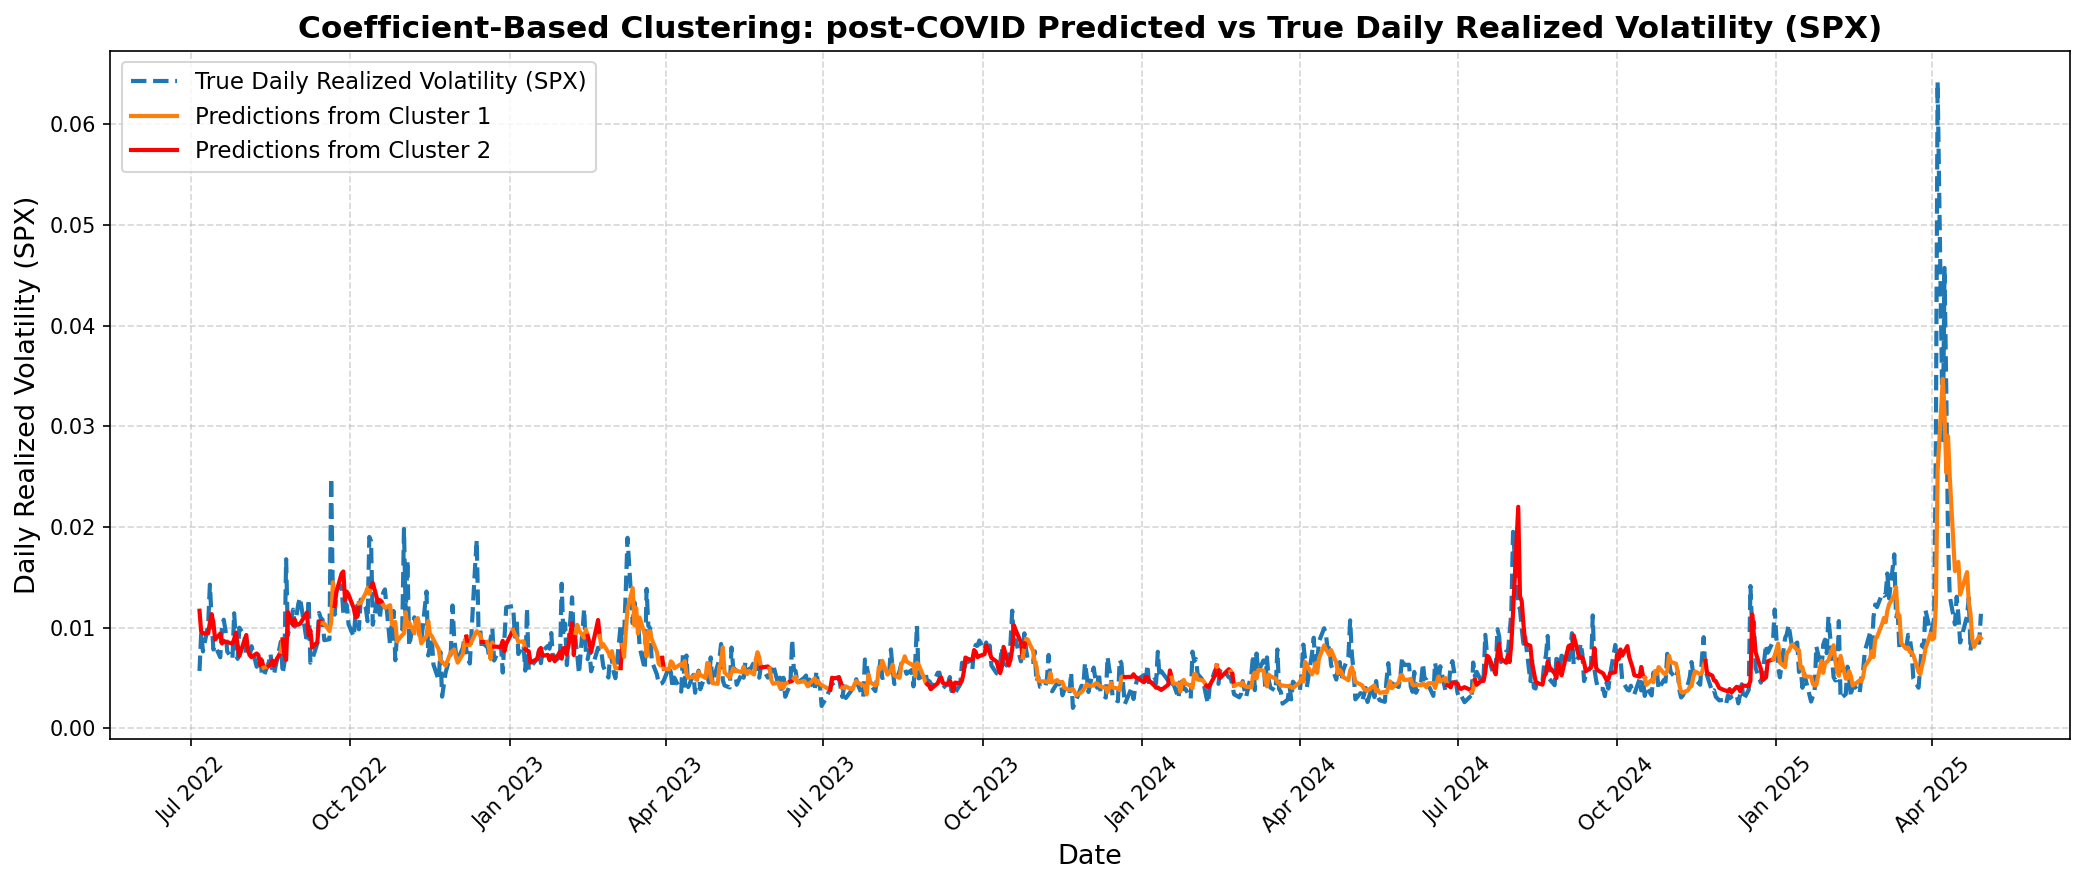

In [273]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Flatten arrays
y_true_is = y_true
y_hat_is = np.array(predictions).flatten()
prediction_dates = X.iloc[prediction_indices].index
test_cluster_labels_all = np.array(xgb_labels).flatten()

cluster_colors = {
    0: '#ff7f0e',
    1: 'red',
    2: 'purple',
    3: 'cyan',
    4: '#ff7f0e',  # standard matplotlib orange
}

true_color = '#1f77b4'  # standard matplotlib blue

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

line_true, = ax.plot(prediction_dates, y_true_is,
                     label='True Daily Realized Volatility (SPX)',
                     linewidth=2, linestyle='--', color=true_color)

start_idx = 0
# Store plotted lines by cluster id for sorting legend later
cluster_lines = {}

for i in range(1, len(y_hat_is)):
    if (test_cluster_labels_all[i] != test_cluster_labels_all[start_idx]) or (i == len(y_hat_is) - 1):
        segment_x = prediction_dates[start_idx:i + 1]
        segment_y = y_hat_is[start_idx:i + 1]
        cluster_id = test_cluster_labels_all[start_idx]
        label = f'Predictions from Cluster {cluster_id + 1}'  # +1 to start at 1
        if cluster_id not in cluster_lines:
            line, = ax.plot(segment_x, segment_y,
                            color=cluster_colors.get(cluster_id, 'black'),
                            linewidth=2,
                            label=label)
            cluster_lines[cluster_id] = line
        else:
            ax.plot(segment_x, segment_y,
                    color=cluster_colors.get(cluster_id, 'black'),
                    linewidth=2)
        start_idx = i

ax.set_title('Coefficient-Based Clustering: post-COVID Predicted vs True Daily Realized Volatility (SPX)', fontsize=15, weight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Daily Realized Volatility (SPX)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Sort cluster lines by cluster id ascending, then add true line first
legend_lines = [line_true] + [cluster_lines[cid] for cid in sorted(cluster_lines)]
legend_labels = [line.get_label() for line in legend_lines]

ax.legend(legend_lines, legend_labels, fontsize=11, loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('Apng_postcovid_clustered_predictions.png', format="png",dpi=400, bbox_inches='tight')

plt.show()


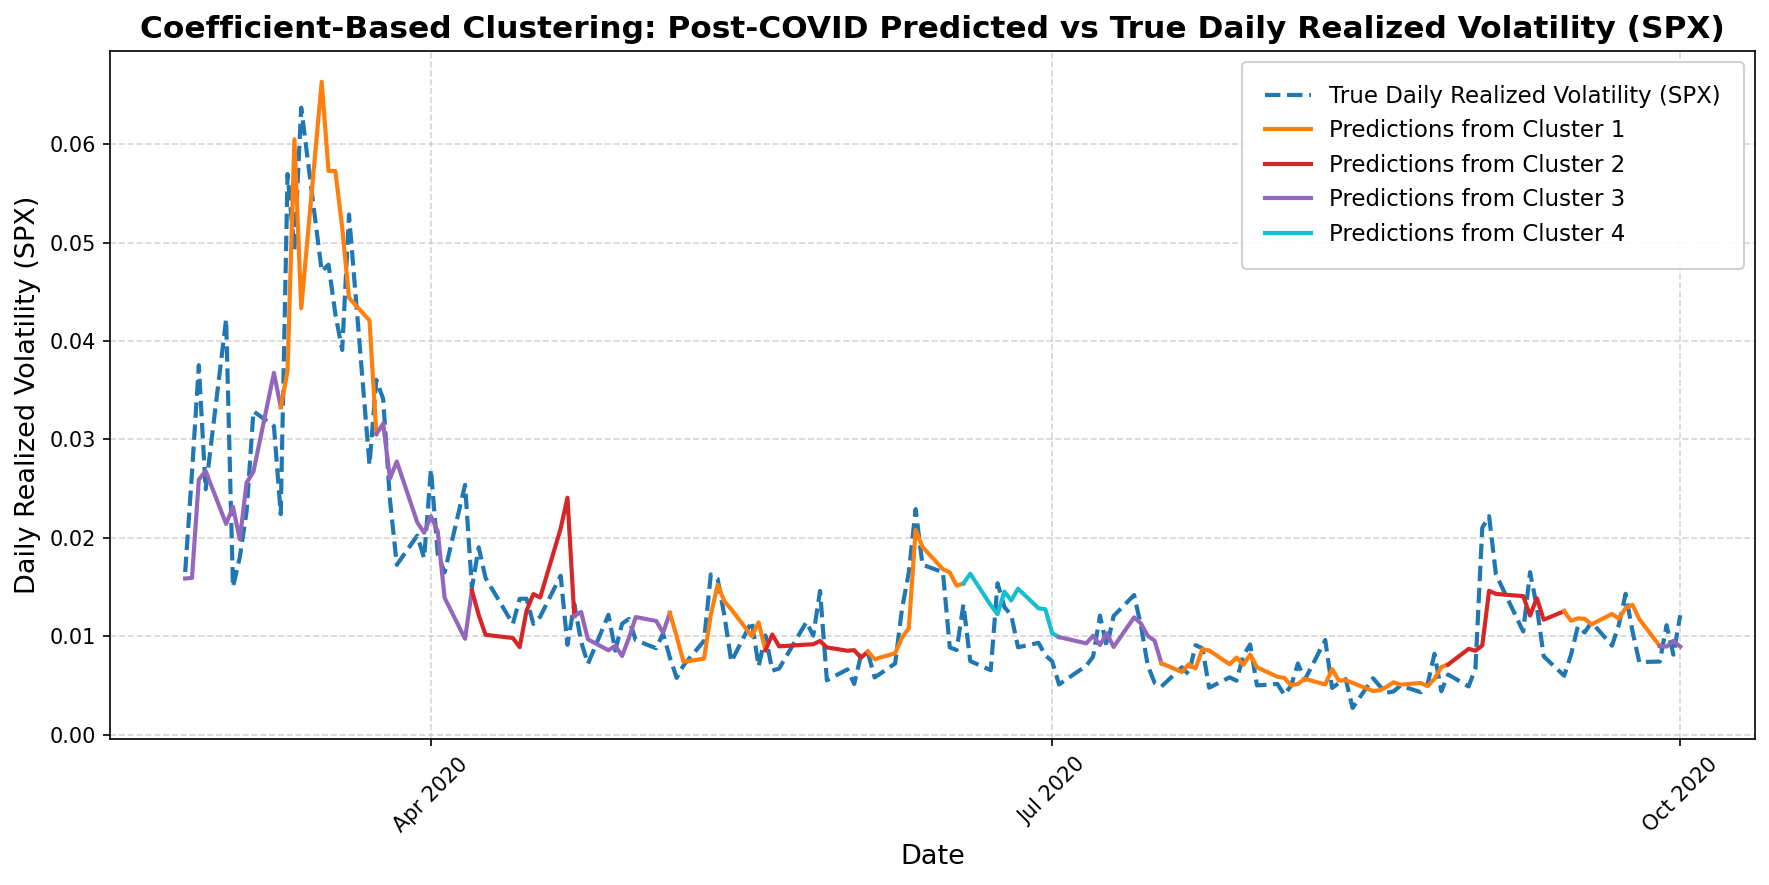

In [248]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Flatten arrays
y_true_is = y_true
y_hat_is = np.array(predictions).flatten()
prediction_dates = X.iloc[prediction_indices].index
test_cluster_labels_all = np.array(xgb_labels).flatten()

# Define 7 distinct cluster colors
cluster_colors = {
    0: '#ff7f0e',  # orange
    1: '#d62728',  # red
    2: '#9467bd',  # purple
    3: '#17becf',  # cyan
    4: '#2ca02c',  # green
    5: '#8c564b',  # brown
    6: '#e377c2',  # pink
}

true_color = '#1f77b4'  # standard matplotlib blue for true line

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

# Plot true line
line_true, = ax.plot(prediction_dates, y_true_is,
                     label='True Daily Realized Volatility (SPX)',
                     linewidth=2, linestyle='--', color=true_color)

start_idx = 0
cluster_lines = {}

for i in range(1, len(y_hat_is)):
    if (test_cluster_labels_all[i] != test_cluster_labels_all[start_idx]) or (i == len(y_hat_is) - 1):
        segment_x = prediction_dates[start_idx:i + 1]
        segment_y = y_hat_is[start_idx:i + 1]
        cluster_id = test_cluster_labels_all[start_idx]
        label = f'Predictions from Cluster {cluster_id + 1}'  # Displayed cluster ID starts at 1
        if cluster_id not in cluster_lines:
            line, = ax.plot(segment_x, segment_y,
                            color=cluster_colors.get(cluster_id, 'black'),
                            linewidth=2,
                            label=label)
            cluster_lines[cluster_id] = line
        else:
            ax.plot(segment_x, segment_y,
                    color=cluster_colors.get(cluster_id, 'black'),
                    linewidth=2)
        start_idx = i

# Title and labels
ax.set_title('Coefficient-Based Clustering: Post-COVID Predicted vs True Daily Realized Volatility (SPX)', fontsize=15, weight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Daily Realized Volatility (SPX)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Build and show legend on the right
legend_lines = [line_true] + [cluster_lines[cid] for cid in sorted(cluster_lines)]
legend_labels = [line.get_label() for line in legend_lines]

ax.legend(
    legend_lines,
    legend_labels,
    fontsize=11,
    loc='upper right',        # inside the axes, top-right corner
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderpad=1
)


plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave room for legend on right
plt.savefig('ACOVID_cluster_predictions.png', format="png",dpi=400, bbox_inches='tight')
plt.show()


In [227]:
import numpy as np
unique_clusters_used = np.unique(xgb_labels)

In [233]:
unique_clusters_used

array([0, 1, 2, 3])

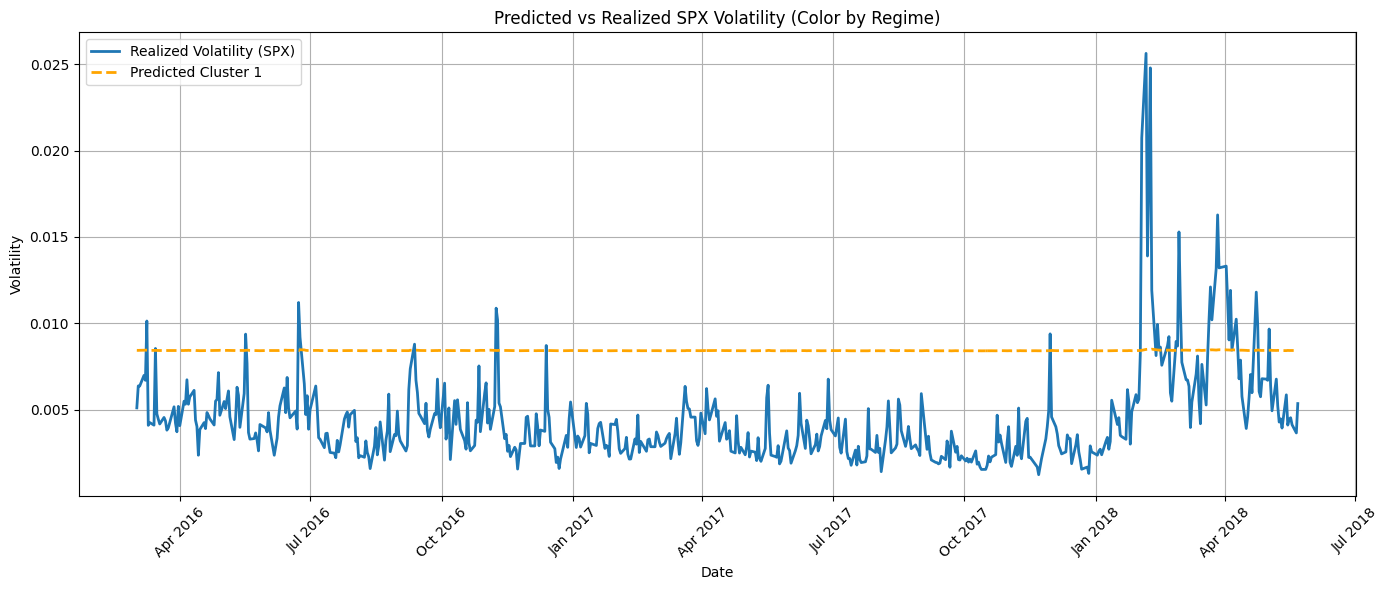

In [88]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Inverse transform
y_true_is = y_true
y_hat_is = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Flatten arrays
y_true_is = y_true_is.flatten()
y_hat_is = y_hat_is.flatten()

# Get datetime index for predictions
prediction_dates = X.iloc[prediction_indices].index

# Define color map
cluster_colors = {0: 'orange', 1: 'orange', 2: 'orange', 3: 'orange', 4: 'orange'}

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, y_true_is, label='Realized Volatility (SPX)', linewidth=2)

test_cluster_labels_all = np.array(test_cluster_labels_all).flatten()

# Plot predicted volatility with color by cluster
start_idx = 0
for i in range(1, len(y_hat_is)):
    if test_cluster_labels_all[i] != test_cluster_labels_all[start_idx] or i == len(y_hat_is) - 1:
        segment_x = prediction_dates[start_idx:i + 1]
        segment_y = y_hat_is[start_idx:i + 1]
        cluster_id = test_cluster_labels_all[start_idx]
        ax.plot(segment_x, segment_y, color=cluster_colors[cluster_id], linewidth=2, linestyle='dashed',
                label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
        start_idx = i

# Set title and labels
ax.set_title('Predicted vs Realized SPX Volatility (Color by Regime)')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.grid(True)

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

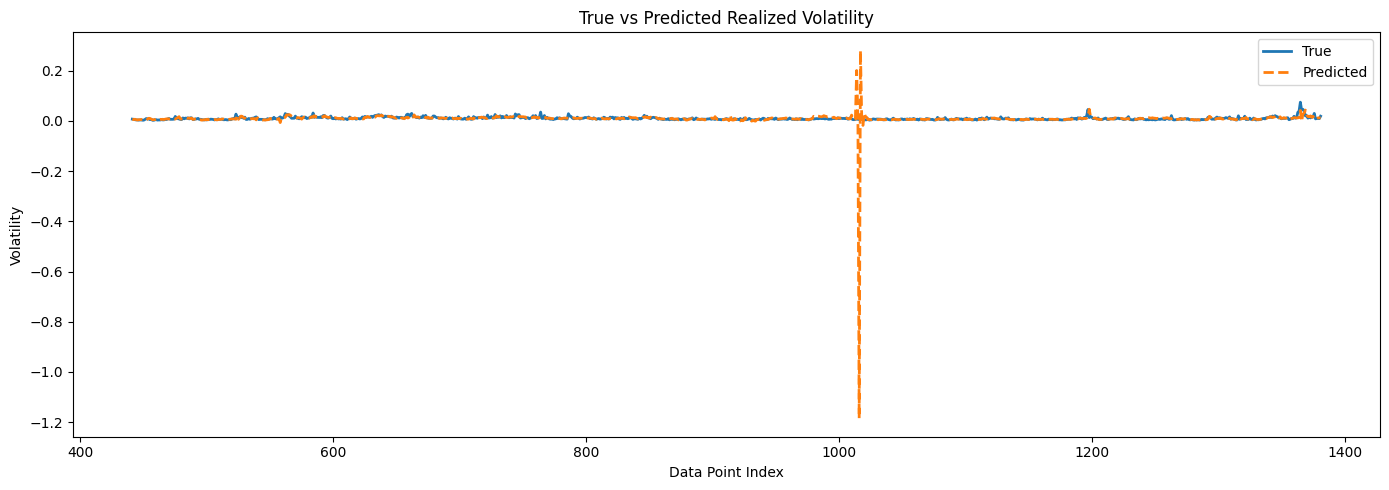

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Build a DataFrame using just index numbers
df_plot = pd.DataFrame({
    'Index': prediction_indices,
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
}).set_index('Index')

# Step 2: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Data Point Index')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
import numpy as np

arr = np.array(y_pred)
np.save('rolling_cluster_predictions.npy', arr)

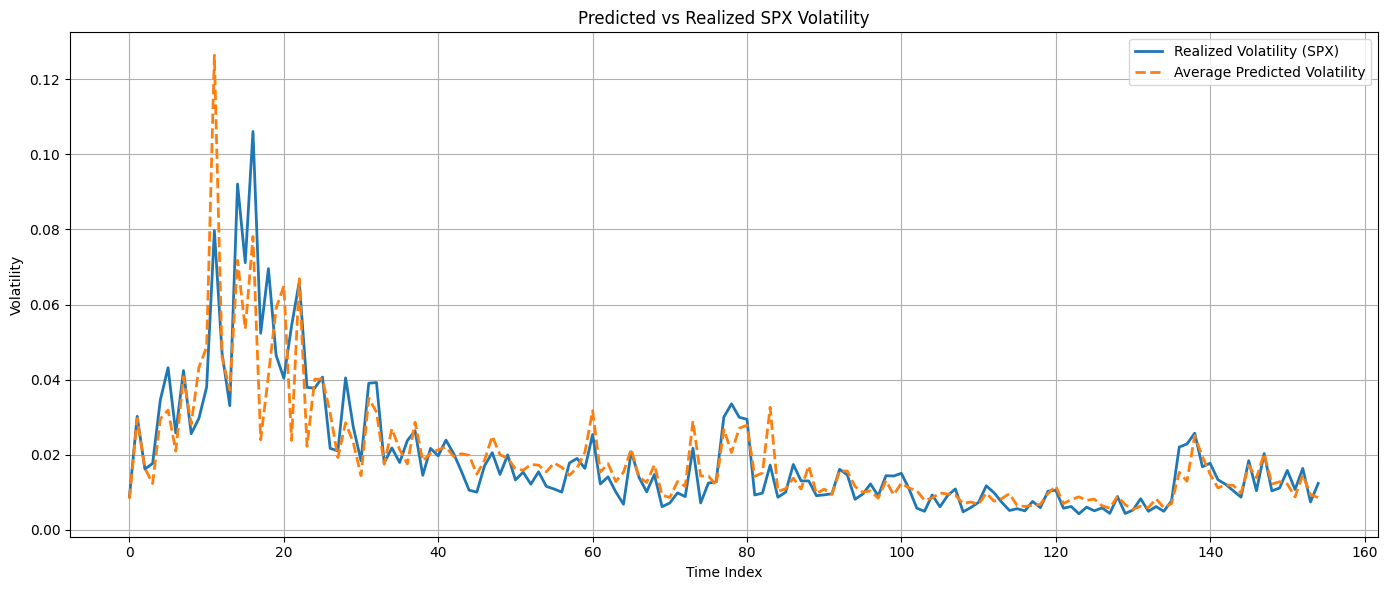

In [52]:
import matplotlib.pyplot as plt
import numpy as np

cluster_predictions = np.load('rolling_cluster_predictions_COVID_3day.npy')
markov_roll_predications = np.load('rolling_markov_XGB_COVID_3.npy')
real_values = np.load('true_COVID.npy')

avg = (cluster_predictions + markov_roll_predications) / 2

plt.figure(figsize=(14, 6))
plt.plot(real_values, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(avg, label='Average Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [194]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(real_values, avg)
print("MAPE: ", mape)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(real_values, avg)
print("MSE: ", mse)

MAPE:  0.24769467632352968
MSE:  6.338485370604345e-05


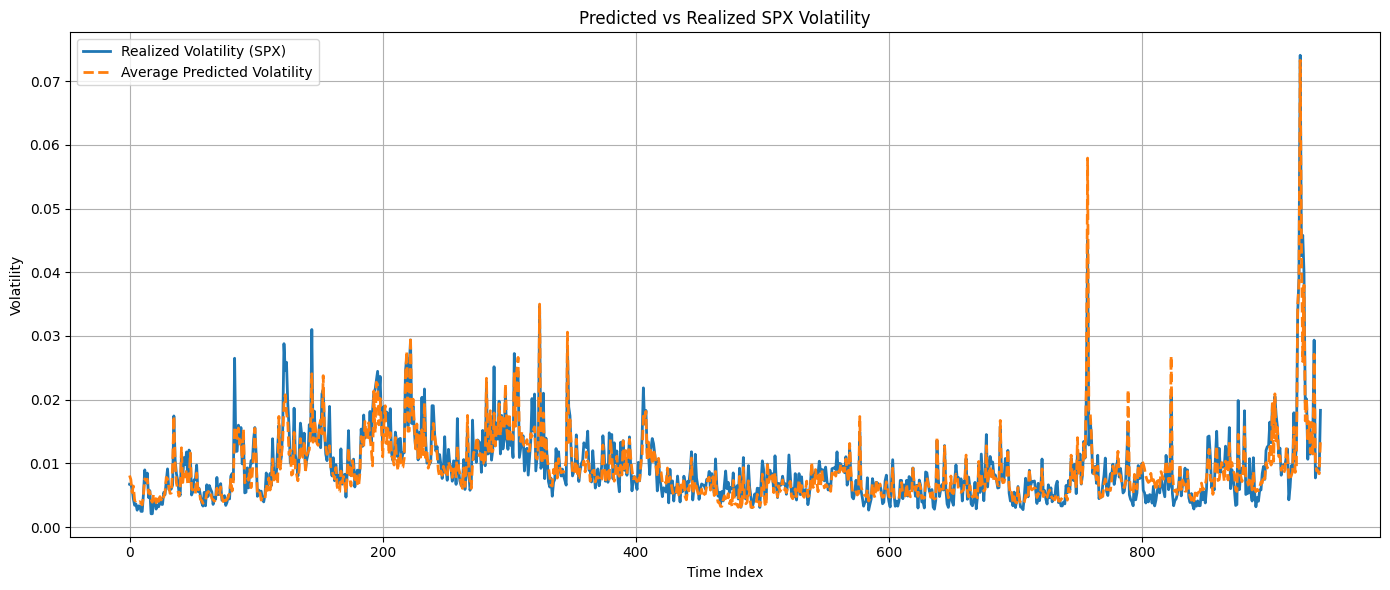

In [67]:
import matplotlib.pyplot as plt
import numpy as np

cluster_predictions = np.load('rolling_cluster_predictions.npy')
vert_predictions = np.load('vert_predictions.npy')
real_values = np.load('markov_true.npy')

avg2 = (cluster_predictions + vert_predictions) / 2

plt.figure(figsize=(14, 6))
plt.plot(real_values, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(avg2, label='Average Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(real_values, avg2)
print("MAPE: ", mape)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(real_values, avg2)
print("MSE: ", mse)

MAPE:  0.1734316717397556
MSE:  4.386385712461784e-06


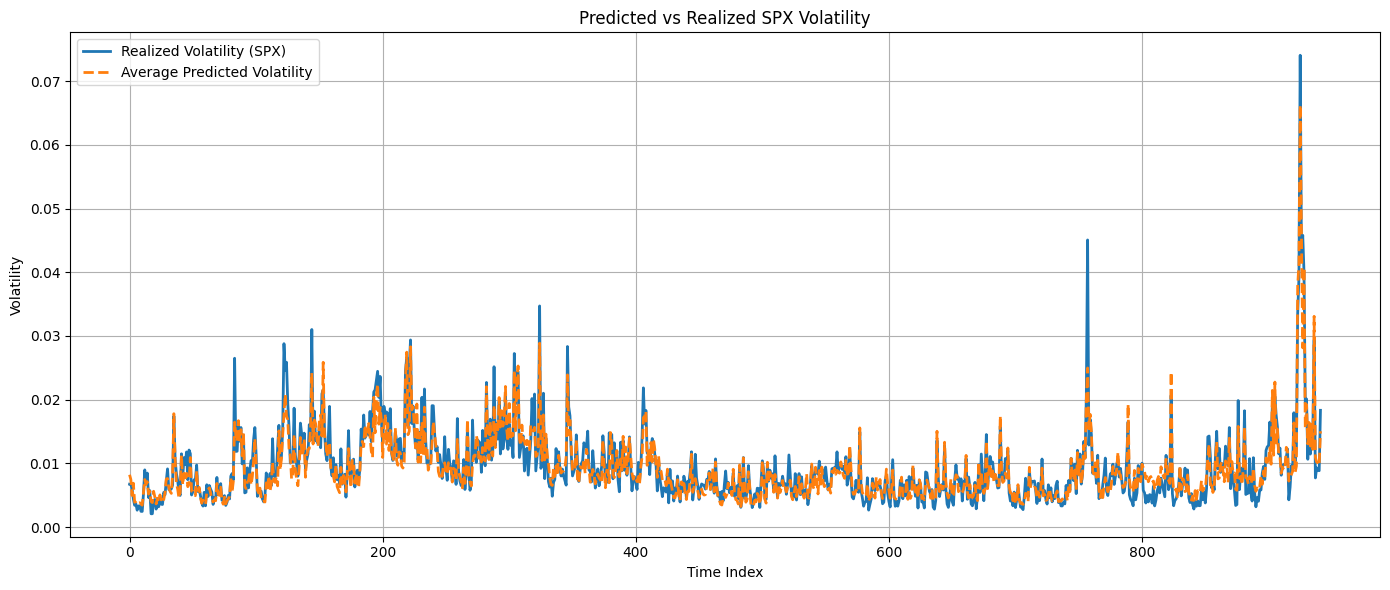

In [124]:
import matplotlib.pyplot as plt
import numpy as np

cluster_predictions = np.load('rolling_cluster_predictions.npy')
vert_predictions = np.load('vert_predictions.npy')
markov_roll_predications = np.load('rolling_markov_XGB.npy')
real_values = np.load('markov_true.npy')

avg3 = (cluster_predictions + vert_predictions + markov_roll_predications) / 3

plt.figure(figsize=(14, 6))
plt.plot(real_values, label='Realized Volatility (SPX)', linewidth=2)
plt.plot(avg3, label='Average Predicted Volatility', linewidth=2, linestyle='--')
plt.title('Predicted vs Realized SPX Volatility')
plt.xlabel('Time Index')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(real_values, avg3)
print("MAPE: ", mape)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(real_values, avg3)
print("MSE: ", mse)

MAPE:  0.16798043144448524
MSE:  4.517009992807032e-06


In [232]:
naive_pred = y.shift(1).dropna()
true_y = y[1:]
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(true_y, naive_pred)
print("Naive MAPE:", mape)

Naive MAPE: 2.5098570880319886


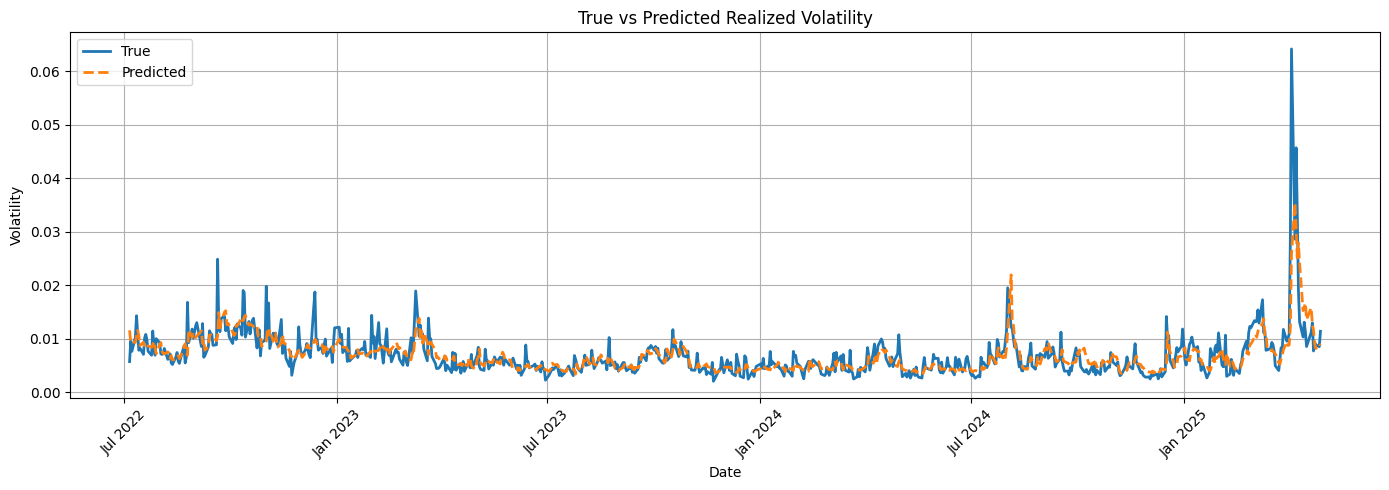

In [286]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Step 1: Get the prediction dates
prediction_dates = y.index[prediction_indices]

y_pred = predictions

# Step 2: Build a DataFrame for easy plotting
df_plot = pd.DataFrame({
    'Date': prediction_dates,
    'True': np.array(y_true).ravel(),
    'Predicted': np.array(y_pred).ravel()
}).set_index('Date')

# Step 3: Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
ax.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')

# ✅ Enforce quarterly ticks

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Labels and formatting
ax.set_title('True vs Predicted Realized Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c491ba08-7b0b-4e77-bbce-46de4cee5dd0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>